# 강원도 지역 한정 날씨 EDA
본 노트북은 전국 기상-산불 데이터셋에서 **강원도 지역(is_gangwon == True)** 데이터로 대상을 한정하고, 태백산맥 기준 **영동 해안권과 영서 내륙권**의 지형적/기상적 차이가 산불 발생 환경 및 진화 난이도에 미치는 국지적 영향을 정밀 규명하기 위해 1번 기본 단계부터 새롭게 구축한 EDA 분석입니다.

In [1]:
# 라이브러리 및 한글 폰트 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy import stats

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("Seaborn 및 Matplotlib 한글 폰트 설정 완료.")

현재 matplotlib font.family: ['Malgun Gothic']
Seaborn 및 Matplotlib 한글 폰트 설정 완료.


In [2]:
# 데이터 경로 설정
BASE_DIR = Path("D:/farm-system-public-02")
DAY_PATH = BASE_DIR / "data/날씨데이터/날씨데이터_일자별_전국산불.csv"
HOUR_PATH = BASE_DIR / "data/날씨데이터/날씨데이터_시간별_전국산불.csv"

In [3]:
# 데이터 로딩 및 강원도 지역 필터링
print("Loading datasets...")
day_df = pd.read_csv(DAY_PATH, encoding="utf-8-sig")
hour_df = pd.read_csv(HOUR_PATH, encoding="utf-8-sig")

SIDO_COL = "발생지역시도명"
ID_COL = "산불아이디"
DATE_COL = "발생일자"
GANGWON_NAMES = ["강원특별자치도", "강원도"]

for df in [day_df, hour_df]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df["발생연도"] = df[DATE_COL].dt.year
    df["발생월"] = df[DATE_COL].dt.month
    df["is_gangwon"] = df[SIDO_COL].isin(GANGWON_NAMES)

# 강원도 데이터 한정 필터링
gw_day = day_df[day_df["is_gangwon"]].copy()
gw_hour = hour_df[hour_df["is_gangwon"]].copy()

# 태백산맥 기준 영동 해안권 vs 영서 내륙권 변수 매핑
yeongdong_districts = ["강릉시", "속초시", "동해시", "삼척시", "태백시", "고성군", "양양군", 
                        "강릉", "속초", "동해", "삼척", "태백", "고성", "양양"]

for df in [gw_day, gw_hour]:
    df["sub_region"] = df["발생지역시군구명"].apply(
        lambda x: "영동 해안" if x in yeongdong_districts else "영서 내륙"
    )

# 분석용 active 데이터 (발생일/발생시각 기준)
day_active = gw_day[gw_day["날짜구분"] == "발생일"].copy()
hour_active = gw_hour[gw_hour["발생시각기준시간"] == 0].copy()

print(f"강원도 일자별(발생일) 데이터 형태: {day_active.shape}")
print(f"강원도 시간별(발생시각) 데이터 형태: {hour_active.shape}")
print(f"영동 해안 산불 표본 수: {len(day_active[day_active['sub_region']=='영동 해안'])}")
print(f"영서 내륙 산불 표본 수: {len(day_active[day_active['sub_region']=='영서 내륙'])}")

Loading datasets...
강원도 일자별(발생일) 데이터 형태: (4139, 52)
강원도 시간별(발생시각) 데이터 형태: (4139, 45)
영동 해안 산불 표본 수: 1609
영서 내륙 산불 표본 수: 2530


## 1. 분석 대상 구분 (영동 vs 영서)
강원도 내에서 영동 해안권과 영서 내륙권 산불 표본의 기본 시공간 분포 특성을 대조합니다. 시군구별 산불 건수, 연도별 발생 건수 비교, 월별 발생 건수 비교, 발생 시간대별 발생 건수 비교를 수행합니다.

=== 강원도 시군구별 산불 발생 건수 ===
발생지역시군구명
동해시    477
양양군    343
평창군    334
원주시    285
홍천군    254
철원군    233
영월군    231
횡성군    230
강릉시    196
삼척시    174
화천군    174
춘천시    123
정선군    110
고성군    101
강릉      98
인제군     79
홍천      72
춘천      59
태백시     55
인제      52
원주      48
삼척      48
고성      43
영월      43
횡성      35
평창      34
정선      30
양구군     30
양양      26
화천      26
철원      25
양구      23
동해      18
태백      14
속초시     10
속초       6
dtype: int64

=== 월별 산불 건수 대조 ===
sub_region  영동 해안  영서 내륙
발생월                     
1             131    111
2             785    780
3             113    242
4             138    415
5              69    173
6              26     47
7               2      3
8               3      2
9               2      6
10            196    626
11             34     58
12            110     67

=== 시간대별 산불 건수 대조 ===
sub_region  영동 해안  영서 내륙
발생시간                    
0               5      3
1               9      3
2              11      4
3              16      2
4           

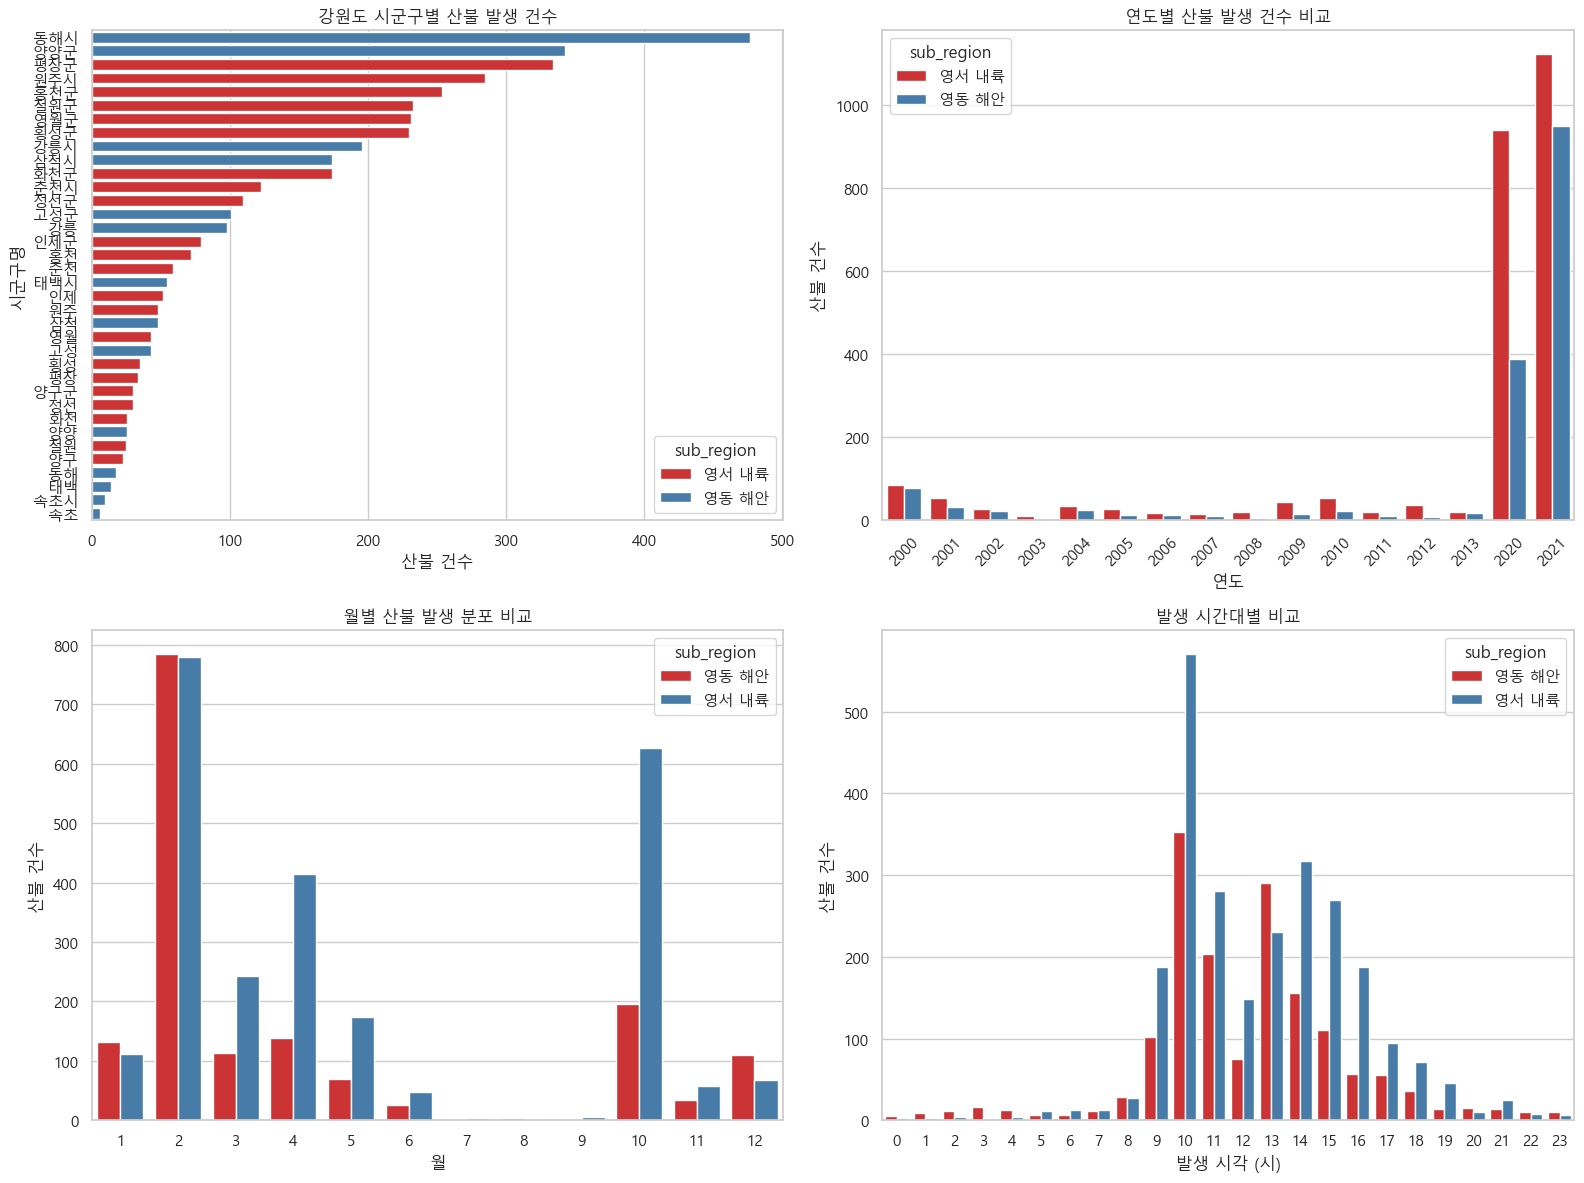

In [4]:
# 1. 분석 대상 구분 및 분포 시각화

# 시군구별 산불 건수
print("=== 강원도 시군구별 산불 발생 건수 ===")
print(day_active.groupby('발생지역시군구명').size().sort_values(ascending=False))

# 영동/영서별 월별 발생 대조
print("\n=== 월별 산불 건수 대조 ===")
print(pd.crosstab(day_active['발생월'], day_active['sub_region']))

# 영동/영서별 시간대별 발생 대조
print("\n=== 시간대별 산불 건수 대조 ===")
print(pd.crosstab(day_active['발생시간'], day_active['sub_region']))

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) 시군구별 산불 건수
sns.countplot(data=day_active, y='발생지역시군구명', order=day_active['발생지역시군구명'].value_counts().index, 
              hue='sub_region', palette=['#e41a1c', '#377eb8'], ax=axes[0, 0])
axes[0, 0].set_title("강원도 시군구별 산불 발생 건수")
axes[0, 0].set_xlabel("산불 건수")
axes[0, 0].set_ylabel("시군구명")

# 2) 연도별 산불 발생 건수 비교
sns.countplot(data=day_active, x='발생연도', hue='sub_region', palette=['#e41a1c', '#377eb8'], ax=axes[0, 1])
axes[0, 1].set_title("연도별 산불 발생 건수 비교")
axes[0, 1].set_xlabel("연도")
axes[0, 1].set_ylabel("산불 건수")
axes[0, 1].tick_params(axis='x', rotation=45)

# 3) 월별 발생 분포 비교
sns.countplot(data=day_active, x='발생월', hue='sub_region', palette=['#e41a1c', '#377eb8'], ax=axes[1, 0])
axes[1, 0].set_title("월별 산불 발생 분포 비교")
axes[1, 0].set_xlabel("월")
axes[1, 0].set_ylabel("산불 건수")

# 4) 발생 시간대별 비교
sns.countplot(data=day_active, x='발생시간', hue='sub_region', palette=['#e41a1c', '#377eb8'], ax=axes[1, 1])
axes[1, 1].set_title("발생 시간대별 비교")
axes[1, 1].set_xlabel("발생 시각 (시)")
axes[1, 1].set_ylabel("산불 건수")

plt.tight_layout()
plt.show()

### 1.1. 분석 대상 구분 결과 및 해석 (플롯 이미지 시각 검토 반영)

- **표본 구성**: 보정 후 강원도 발생일 표본은 **4,139건**이며, 영동 해안 **1,609건**, 영서 내륙 **2,530건**입니다.
- **시군구 분포**: 원자료 시군구명은 `동해시/동해`, `강릉시/강릉`처럼 표기가 분리되어 있어 해석 시 정규화가 필요합니다. 원자료 표기 그대로는 **동해시 477건**, **양양군 343건**, **평창군 334건**이 상위에 나타납니다. 따라서 시군구 순위는 표준화 전까지 절대 순위보다 공간적 집중 경향 확인용으로 제한합니다.
- **월별 분포**: 영동과 영서 모두 **2월** 피크가 매우 큽니다(영동 785건, 영서 780건). 영서 내륙은 **10월 626건**의 가을 피크가 특히 강하고, 영동 해안도 10월 196건의 2차 피크를 보입니다.
- **시간대 분포**: 10~15시 사이 발생이 강원도 전체의 약 **72.6%**를 차지합니다. 영동은 10시와 13시 피크가 크고, 영서는 10시와 14~15시 피크가 큽니다. 주간 활동 시간대와 국지풍 발달 시간이 함께 반영된 분포로 해석됩니다.


## 2. 일자별 날씨 변수 비교 (영동 vs 영서)
산불 발생일 기준 일자별 평균기온, 최고/최저기온, 습도, 강수량, 풍속, 최대풍속 등 주요 변수의 기술통계량을 비교하고, 특히 산불이 집중되는 건조기(11월 ~ 5월)로 필터링했을 때 기상 특징이 영동과 영서 간에 어떻게 달라지는지 Boxplot을 통해 시각화합니다.

=== 강원 영동 vs 영서 발생일 기준 기상 기술통계 대조 (전체 기간) ===

[평균 기온] 기술통계
             count      mean       std        min       25%       50%  \
sub_region                                                              
영동 해안       1609.0  6.010204  6.976786 -11.193019 -0.858724  7.050351   
영서 내륙       2530.0  5.343719  7.418801 -16.846897 -0.894541  7.201269   

                  75%        max  
sub_region                        
영동 해안       11.495216  29.432334  
영서 내륙        9.600204  25.894728  

[최소 상대습도] 기술통계
             count       mean        std       min        25%        50%  \
sub_region                                                                 
영동 해안       1609.0  26.669635  14.151670  6.445661  14.961451  23.632024   
영서 내륙       2530.0  31.613279  14.384315  5.081162  20.456772  28.989591   

                  75%        max  
sub_region                        
영동 해안       35.029659  89.637961  
영서 내륙       41.953278  99.849440  

[평균 풍속] 기술통계
             count      mean    

C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\3192012553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0, 0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\3192012553.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_dry, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0, 1])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\3192012553.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='sub_regio

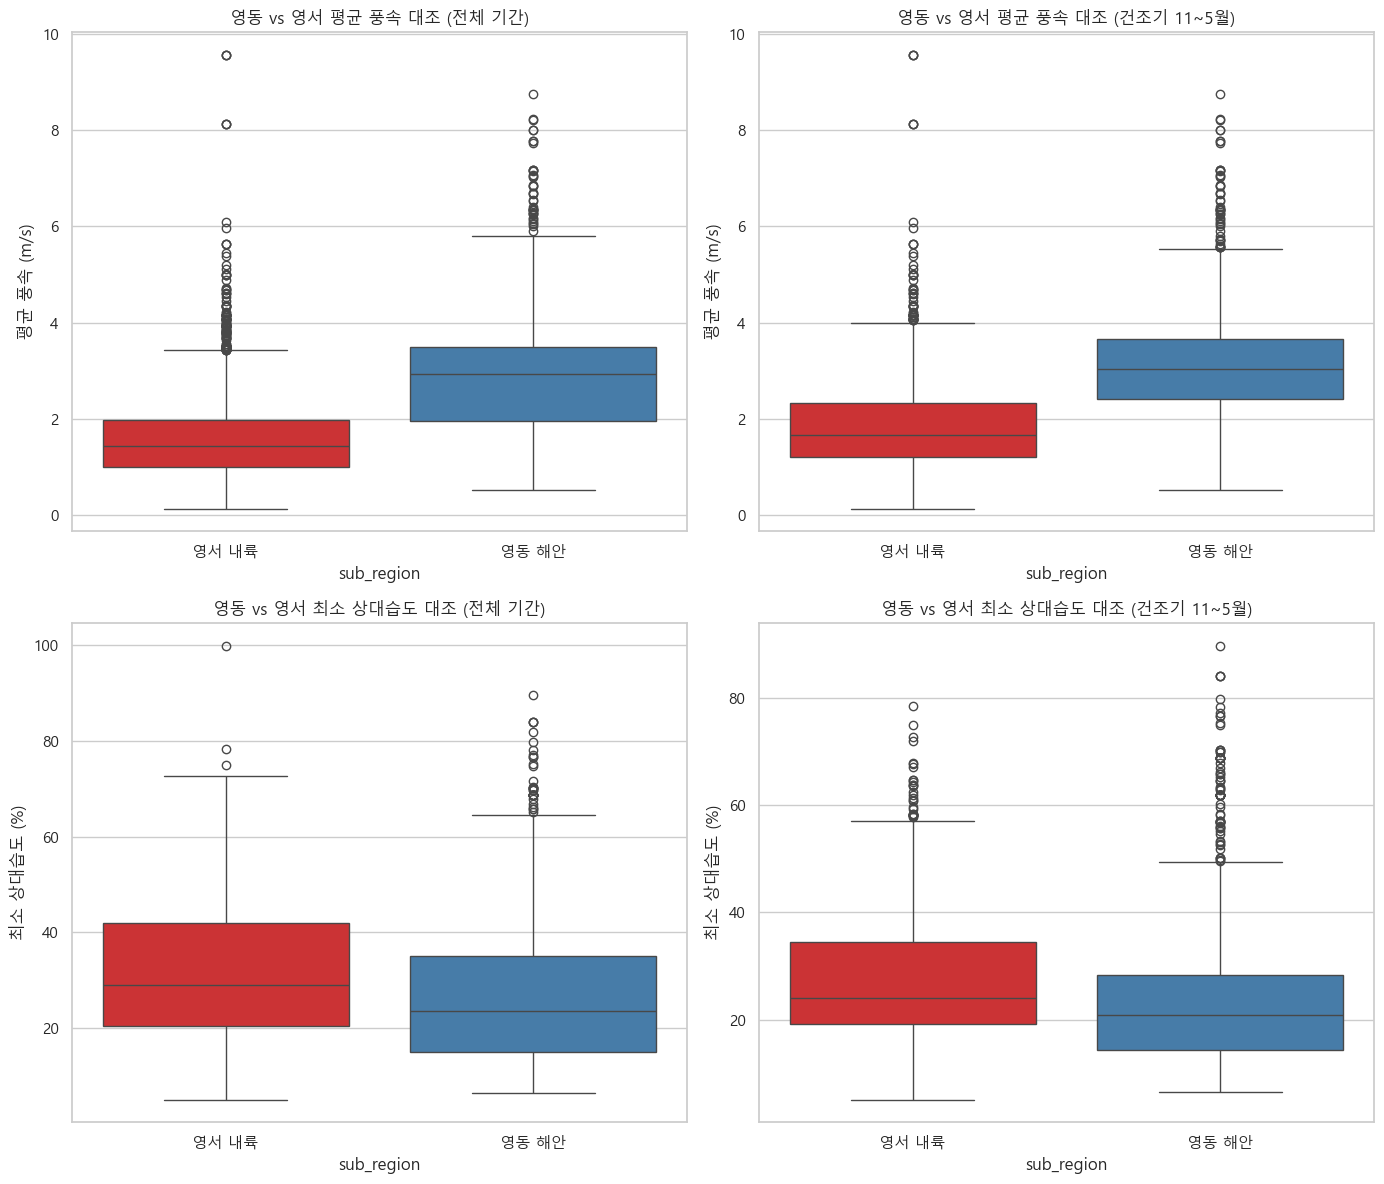

In [5]:
# 2. 일자별 주요 기상 인자 대조
cols_to_compare = ['평균 기온', '최소 상대습도', '평균 풍속', '최대 순간풍속', '일강수량']

print("=== 강원 영동 vs 영서 발생일 기준 기상 기술통계 대조 (전체 기간) ===")
for col in cols_to_compare:
    print(f"\n[{col}] 기술통계")
    print(day_active.groupby('sub_region')[col].describe(percentiles=[0.25, 0.5, 0.75]))

# 건조기/산불조심기간 (11월 ~ 5월) 필터링
day_dry = day_active[day_active['발생월'].isin([11, 12, 1, 2, 3, 4, 5])].copy()
print(f"\n건조기(11월~5월) 필터링 후 표본 수: 영동={len(day_dry[day_dry['sub_region']=='영동 해안'])}, 영서={len(day_dry[day_dry['sub_region']=='영서 내륙'])}")

# 시각화 (전체 기간 vs 건조기)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) 평균 풍속 비교
sns.boxplot(data=day_active, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0, 0])
axes[0, 0].set_title("영동 vs 영서 평균 풍속 대조 (전체 기간)")
axes[0, 0].set_ylabel("평균 풍속 (m/s)")

sns.boxplot(data=day_dry, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0, 1])
axes[0, 1].set_title("영동 vs 영서 평균 풍속 대조 (건조기 11~5월)")
axes[0, 1].set_ylabel("평균 풍속 (m/s)")

# 2) 최소 상대습도 비교
sns.boxplot(data=day_active, x='sub_region', y='최소 상대습도', palette=['#e41a1c', '#377eb8'], ax=axes[1, 0])
axes[1, 0].set_title("영동 vs 영서 최소 상대습도 대조 (전체 기간)")
axes[1, 0].set_ylabel("최소 상대습도 (%)")

sns.boxplot(data=day_dry, x='sub_region', y='최소 상대습도', palette=['#e41a1c', '#377eb8'], ax=axes[1, 1])
axes[1, 1].set_title("영동 vs 영서 최소 상대습도 대조 (건조기 11~5월)")
axes[1, 1].set_ylabel("최소 상대습도 (%)")

plt.tight_layout()
plt.show()

### 2.1. 일자별 날씨 변수 비교 결과 및 해석 (플롯 이미지 시각 검토 반영)

- **풍속 격차**: 발생일 평균 풍속은 영동 해안 **2.94m/s**, 영서 내륙 **1.64m/s**입니다. 박스플롯에서도 영동의 중앙값 **2.93m/s**가 영서 **1.43m/s**보다 약 2배 높고, 건조기에도 같은 차이가 유지됩니다.
- **건조도 격차**: 최소 상대습도 평균은 영동 **26.67%**, 영서 **31.61%**입니다. 영동의 중앙값은 **23.63%**, 75% 분위도 **35.03%**로 낮아, 상당수 산불이 저습 조건에서 발생했습니다.
- **돌풍 조건**: 최대 순간풍속 평균은 영동 **10.93m/s**, 영서 **8.02m/s**입니다. 영동은 평균풍뿐 아니라 순간 돌풍도 강해, 화선 확산과 비화 위험을 높이는 조건이 더 자주 동반됩니다.
- **강수량**: 발생일 일강수량은 두 지역 모두 중앙값 0입니다. 강수 변수는 평균 차이보다 무강수 사건이 대부분이라는 점이 중요합니다.


## 3. 시간별 날씨 변수 비교 (영동 vs 영서)
산불 발생 시각(0h) 기준 기온, 습도, 풍속 등의 분포를 비교하고, 발생 전 24시간부터 발생 후 24시간까지 시간대별로 묶은 시계열 평균 기상 추이를 라인 플롯(Line plot)으로 분석하여 영동 지방에서 나타나는 급격한 기상 쇼크(급건조화 및 강풍 상승) 패턴을 영서와 대조하여 확인합니다.

=== 발생 시각(0h) 기준 기상 통계 대조 ===
                  기온         습도        풍속        현지기압
sub_region                                           
영동 해안       8.065807  38.302993  3.166054  994.055849
영서 내륙       8.846482  45.150137  2.044007  985.144110


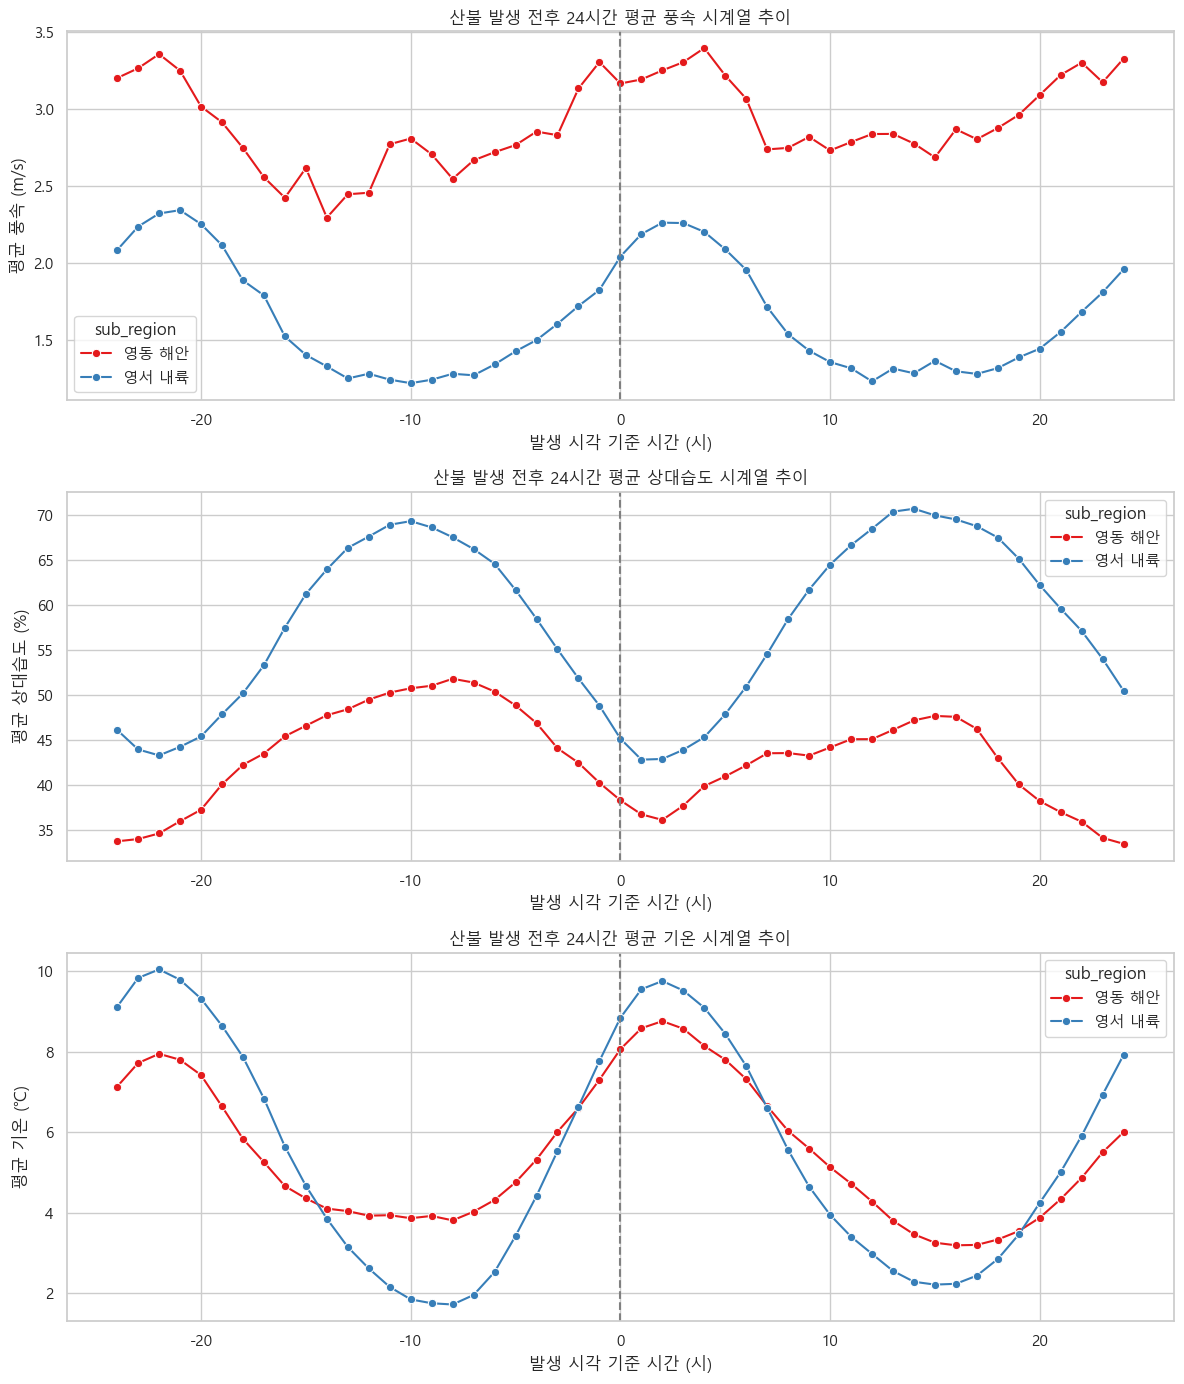

In [6]:
# 3. 시간별 날씨 변수 비교 및 발생 전후 시계열 추이 분석

print("=== 발생 시각(0h) 기준 기상 통계 대조 ===")
print(hour_active.groupby('sub_region')[['기온', '습도', '풍속', '현지기압']].mean())

# 발생 전후 24시간 범위 필터링 (-24h ~ +24h)
ts_df = gw_hour[(gw_hour['발생시각기준시간'] >= -24) & (gw_hour['발생시각기준시간'] <= 24)].copy()

# 시간대별 평균 산출
ts_mean = ts_df.groupby(['발생시각기준시간', 'sub_region'])[['풍속', '습도', '기온']].mean().reset_index()

# 시각화
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# 1) 풍속 시계열
sns.lineplot(data=ts_mean, x='발생시각기준시간', y='풍속', hue='sub_region', 
             palette=['#e41a1c', '#377eb8'], marker='o', ax=axes[0])
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1.5)
axes[0].set_title("산불 발생 전후 24시간 평균 풍속 시계열 추이")
axes[0].set_xlabel("발생 시각 기준 시간 (시)")
axes[0].set_ylabel("평균 풍속 (m/s)")

# 2) 습도 시계열
sns.lineplot(data=ts_mean, x='발생시각기준시간', y='습도', hue='sub_region', 
             palette=['#e41a1c', '#377eb8'], marker='o', ax=axes[1])
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_title("산불 발생 전후 24시간 평균 상대습도 시계열 추이")
axes[1].set_xlabel("발생 시각 기준 시간 (시)")
axes[1].set_ylabel("평균 상대습도 (%)")

# 3) 기온 시계열
sns.lineplot(data=ts_mean, x='발생시각기준시간', y='기온', hue='sub_region', 
             palette=['#e41a1c', '#377eb8'], marker='o', ax=axes[2])
axes[2].axvline(0, color='gray', linestyle='--', linewidth=1.5)
axes[2].set_title("산불 발생 전후 24시간 평균 기온 시계열 추이")
axes[2].set_xlabel("발생 시각 기준 시간 (시)")
axes[2].set_ylabel("평균 기온 (℃)")

plt.tight_layout()
plt.show()

### 3.1. 시간별 날씨 변수 비교 결과 및 해석 (플롯 이미지 시각 검토 반영)

- **발생시각 단면**: 발생시각(0h) 평균 풍속은 영동 해안 **3.17m/s**, 영서 내륙 **2.04m/s**입니다. 습도는 영동 **38.30%**, 영서 **45.15%**로 영동이 더 건조합니다.
- **야간 강풍 지속성**: 시계열 플롯에서 영동 해안은 발생 전 야간에도 풍속이 영서보다 높게 유지되고, 발생시각 전후로 3m/s 이상의 구간이 넓게 이어집니다. 영서 내륙은 야간 풍속이 상대적으로 낮게 안정됩니다.
- **수분 복원력 차이**: 영서 내륙은 밤 사이 습도가 60~70%대로 회복되는 반면, 영동 해안은 야간에도 상대습도가 낮은 수준에 머물고 발생시점 부근에 더 건조해집니다.
- **결론**: 영동 해안은 낮에만 위험한 것이 아니라, 야간부터 바람과 저습이 이어져 연료 수분 회복을 제한하는 구조가 확인됩니다.


## 4. 가설 검증 및 국지적 기상 분석 (T-Test & 8방위 풍향)
영동 해안 지역의 바람이 영서 내륙 대비 통계적으로 유의미하게 강력하고 건조한지 t-검정(독립표본 t-test, equal_var=False)을 수행하고, 풍향 분포를 극좌표(Polar plot) 상에 8방위로 시각화하여 영동 지방 양간지풍의 국지적 바람길 영향을 시각적으로 실증합니다.

[평균 풍속] 독립표본 t-검정: t=37.5075, p=1.1123e-251
[최소 상대습도] 독립표본 t-검정: t=-10.8855, p=3.7001e-27


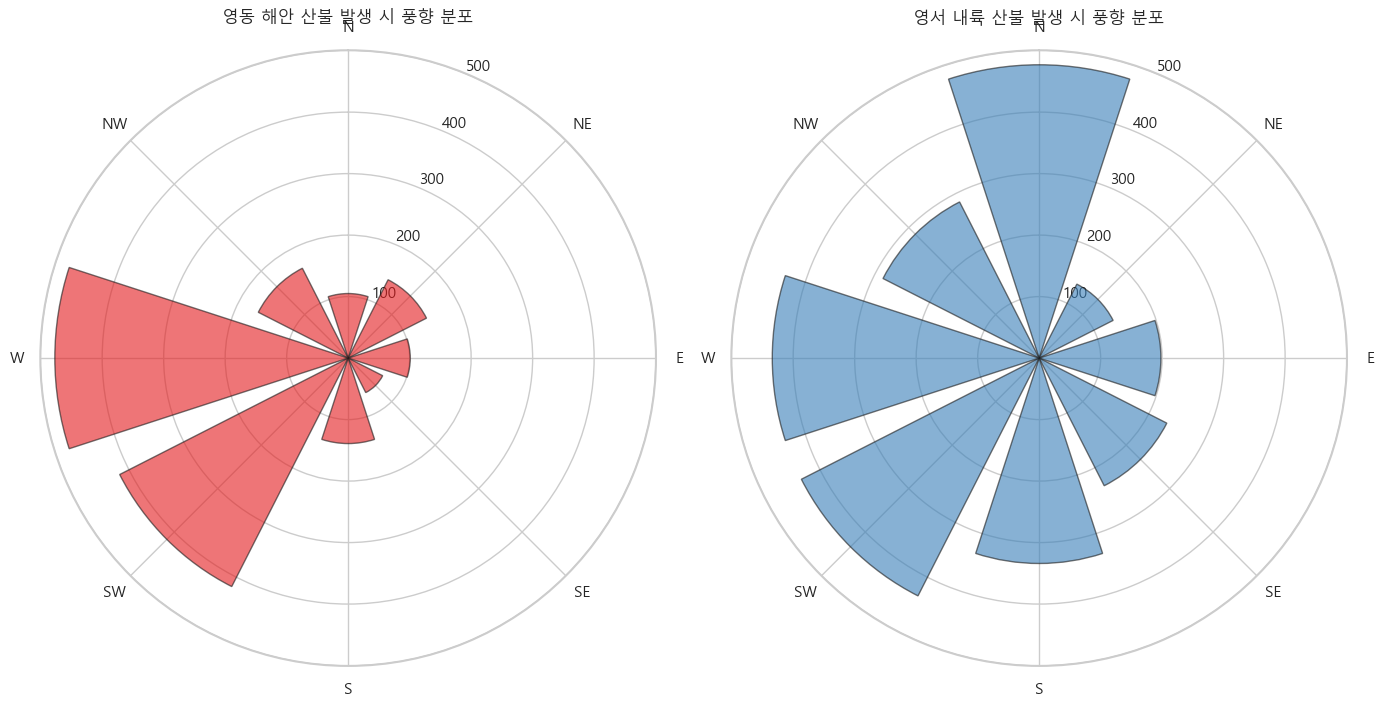

In [7]:
# 4. 가설 검증 (T-Test) 및 풍향 방위 비교

# 4.1. T-Test
yd_wind = day_active[day_active['sub_region']=='영동 해안']['평균 풍속'].dropna()
ys_wind = day_active[day_active['sub_region']=='영서 내륙']['평균 풍속'].dropna()
t_w, p_w = stats.ttest_ind(yd_wind, ys_wind, equal_var=False)
print(f"[평균 풍속] 독립표본 t-검정: t={t_w:.4f}, p={p_w:.4e}")

yd_rh = day_active[day_active['sub_region']=='영동 해안']['최소 상대습도'].dropna()
ys_rh = day_active[day_active['sub_region']=='영서 내륙']['최소 상대습도'].dropna()
t_h, p_h = stats.ttest_ind(yd_rh, ys_rh, equal_var=False)
print(f"[최소 상대습도] 독립표본 t-검정: t={t_h:.4f}, p={p_h:.4e}")

# 4.2. 풍향 8방위 분석 및 극좌표 시각화
def deg_to_8direction(deg):
    if pd.isnull(deg):
        return np.nan
    deg = deg % 360
    # 8방위 기준 (각 방위 45도 간격)
    # 북(N): 337.5 ~ 22.5
    # 북동(NE): 22.5 ~ 67.5
    # 동(E): 67.5 ~ 112.5
    # 남동(SE): 112.5 ~ 157.5
    # 남(S): 157.5 ~ 202.5
    # 남서(SW): 202.5 ~ 247.5
    # 서(W): 247.5 ~ 292.5
    # 북서(NW): 292.5 ~ 337.5
    directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((deg + 22.5) / 45) % 8
    return directions[idx]

# 발생 시각의 풍향 매핑
hour_active = hour_active.copy()
hour_active['풍향방위'] = hour_active['풍향'].apply(deg_to_8direction)

# 방위별 발생 빈도 집계
directions_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
dir_counts = hour_active.groupby(['sub_region', '풍향방위']).size().unstack(fill_value=0)
dir_counts = dir_counts.reindex(columns=directions_order, fill_value=0)

# 극좌표 시각화
theta = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
width = np.pi / 5

fig = plt.figure(figsize=(14, 7))

for i, sub_reg in enumerate(['영동 해안', '영서 내륙']):
    ax = fig.add_subplot(1, 2, i + 1, projection='polar')
    counts = dir_counts.loc[sub_reg].values
    bars = ax.bar(theta, counts, width=width, bottom=0.0, 
                  color='#e41a1c' if i==0 else '#377eb8', alpha=0.6, edgecolor='k')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1) # 시계 방향
    ax.set_thetagrids(np.degrees(theta), directions_order)
    ax.set_title(f"{sub_reg} 산불 발생 시 풍향 분포", pad=20)

plt.tight_layout()
plt.show()

### 4.1. 가설 검증 및 국지 기상 결과 해석 (플롯 이미지 시각 검토 반영)

- **평균 풍속 검정**: 영동 해안 평균 풍속 **2.94m/s**는 영서 내륙 **1.64m/s**보다 유의하게 높습니다($t=37.51$, $p=1.11e-251$).
- **최소 상대습도 검정**: 영동 해안 최소 상대습도 **26.67%**는 영서 내륙 **31.61%**보다 유의하게 낮습니다($t=-10.89$, $p=3.70e-27$).
- **풍향 분포**: Polar plot에서 영동 해안은 W/SW 계열이 강하게 집중되어 태백산맥을 넘는 서풍계 바람길 신호가 뚜렷합니다. 영서 내륙은 북풍과 서풍계가 혼재해 상대적으로 분산된 구조입니다.
- **해석**: 강원도 내부에서도 위험 기상은 균질하지 않습니다. 영동 해안권은 강풍과 저습이 함께 나타나는 별도 메커니즘으로 분리해 모델링해야 합니다.


## 5. 상관관계 및 시각화 종합 (Heatmap & 진화시간 회귀선)
영동과 영서의 주요 기상 요인 간 상관 메커니즘을 규명하는 Heatmap을 비교 분석하고, 기상 강도(풍속)에 따른 실제 산불의 진화 난이도(`진화소요시간시`) 증가 경향을 lmplot 회귀선을 통해 영동과 영서 간에 대조 분석합니다.

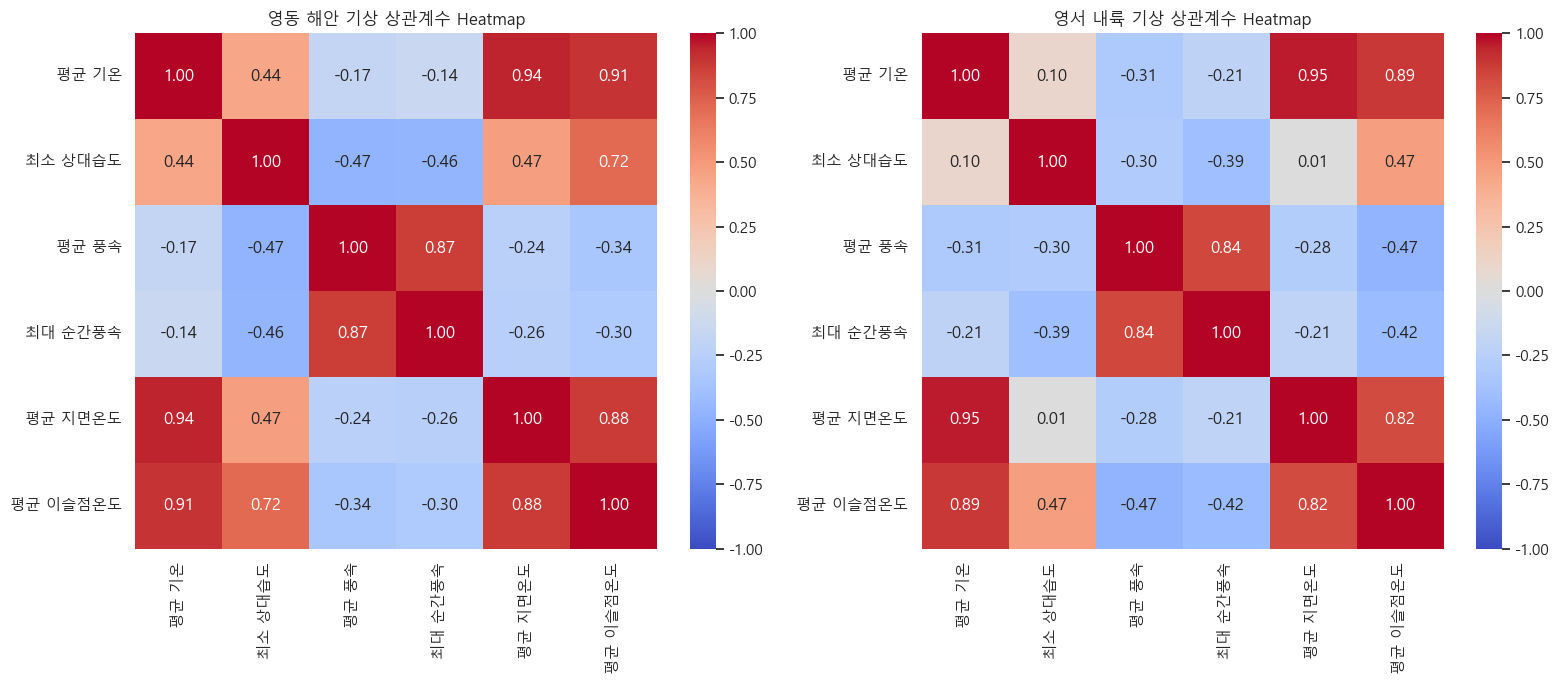

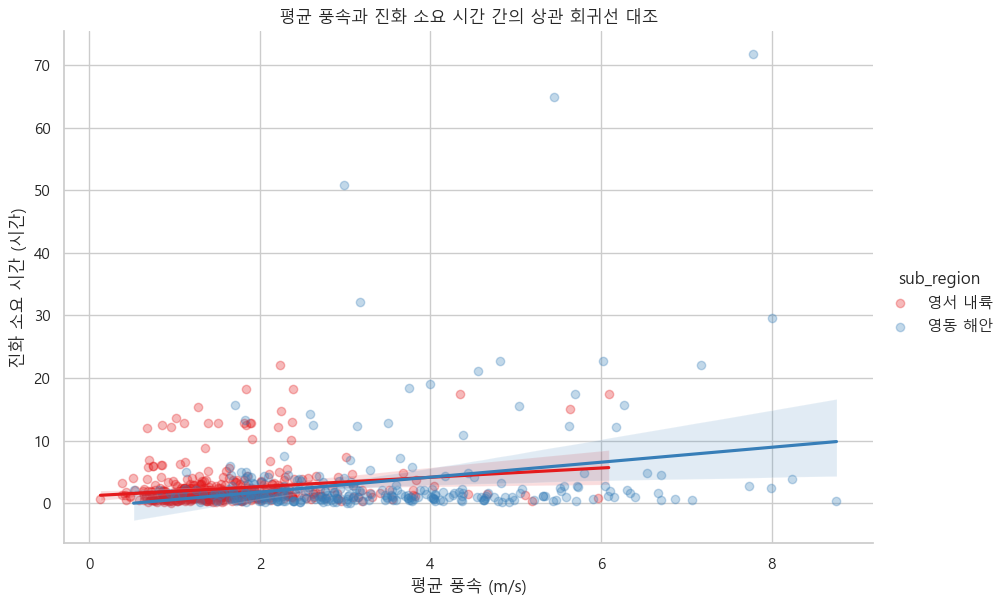

In [8]:
# 5. 상관관계 및 진화시간 회귀 대조
corr_cols = ['평균 기온', '최소 상대습도', '평균 풍속', '최대 순간풍속', '평균 지면온도', '평균 이슬점온도']

yd_corr = day_active[day_active['sub_region']=='영동 해안'][corr_cols].corr()
ys_corr = day_active[day_active['sub_region']=='영서 내륙'][corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(yd_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("영동 해안 기상 상관계수 Heatmap")

sns.heatmap(ys_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("영서 내륙 기상 상관계수 Heatmap")
plt.tight_layout()
plt.show()  # Heatmap 플롯을 먼저 화면에 출력하고 닫음

# 진화시간 유효 데이터 필터링
valid_duration = day_active.dropna(subset=['진화소요시간시']).copy()

# 풍속과 진화소요시간 간의 회귀선 비교 (lmplot은 독립적인 Figure를 생성)
sns.lmplot(data=valid_duration, x='평균 풍속', y='진화소요시간시', hue='sub_region', 
           palette=['#e41a1c', '#377eb8'], height=6, aspect=1.5, scatter_kws={'alpha': 0.3})
plt.title("평균 풍속과 진화 소요 시간 간의 상관 회귀선 대조")
plt.xlabel("평균 풍속 (m/s)")
plt.ylabel("진화 소요 시간 (시간)")
plt.show()


### 5.1. 상관관계 및 시각화 종합 해석 (플롯 이미지 시각 검토 반영)

- **상관 구조**: 영동 해안은 평균 풍속과 최소 상대습도, 최대 순간풍속과 최소 상대습도 사이의 음의 상관이 뚜렷합니다. 바람이 강할수록 건조해지는 푄/양간지풍형 결합이 영서보다 강하게 나타납니다.
- **진화시간 회귀 플롯**: 영동 해안은 평균 풍속 4m/s 이상 구간까지 표본이 넓게 퍼지고, 진화소요시간의 상방 꼬리도 길게 나타납니다. 영서 내륙은 낮은 풍속 구간에 표본이 더 조밀합니다.
- **해석 제한**: 진화소요시간은 결측이 많아 유효 표본 기준 해석입니다. 회귀선 자체보다 고풍속 구간에서 장시간 진화 아웃라이어가 늘어나는 **꼬리 위험**을 주목해야 합니다.


## 6. 지면 및 지중 열적 조건 분석 (Surface & Soil Conditions)
본 섹션에서는 지표면 낙엽 연료의 건조에 기여하는 지표 복사 가열 편차(`지면온도편차`)와 야간 복사 냉각(`최저 초상온도`)을 대조하고, 지층 수분 탈수를 대변하는 `지중 온도 수직 구배 (5cm - 30cm)`를 분석합니다.

### 6.1. 접지 기온(최저 초상온도) 및 지면온도 편차 분석

=== 지면온도편차 기술통계 (영동 vs 영서) ===
             count      mean       std       min       25%       50%  \
sub_region                                                             
영동 해안       1609.0  0.939244  2.751080 -5.287896 -1.169980  1.000794   
영서 내륙       2530.0  3.069025  2.415982 -3.804484  1.541372  3.113117   

                 75%        max  
sub_region                       
영동 해안       2.843637  11.132097  
영서 내륙       4.763497  11.210188  

T-test (지면온도편차 영동 vs 영서): t=-25.4359, p=8.8435e-130

=== 최저 초상온도 기술통계 (영동 vs 영서) ===
             count      mean       std        min       25%       50%  \
sub_region                                                              
영동 해안       1609.0 -1.808784  6.796677 -19.273593 -8.292116 -1.293781   
영서 내륙       2530.0 -3.005695  6.573535 -23.964703 -7.951832 -3.064546   

                 75%        max  
sub_region                       
영동 해안       2.446471  20.494657  
영서 내륙       0.999434  22.420075  

T-test (최저 초상온도 영동 vs 영서): t

C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\4051810757.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='sub_region', y='지면온도편차', palette=['#e41a1c', '#377eb8'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\4051810757.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='sub_region', y='최저 초상온도', palette=['#e41a1c', '#377eb8'], ax=axes[1])


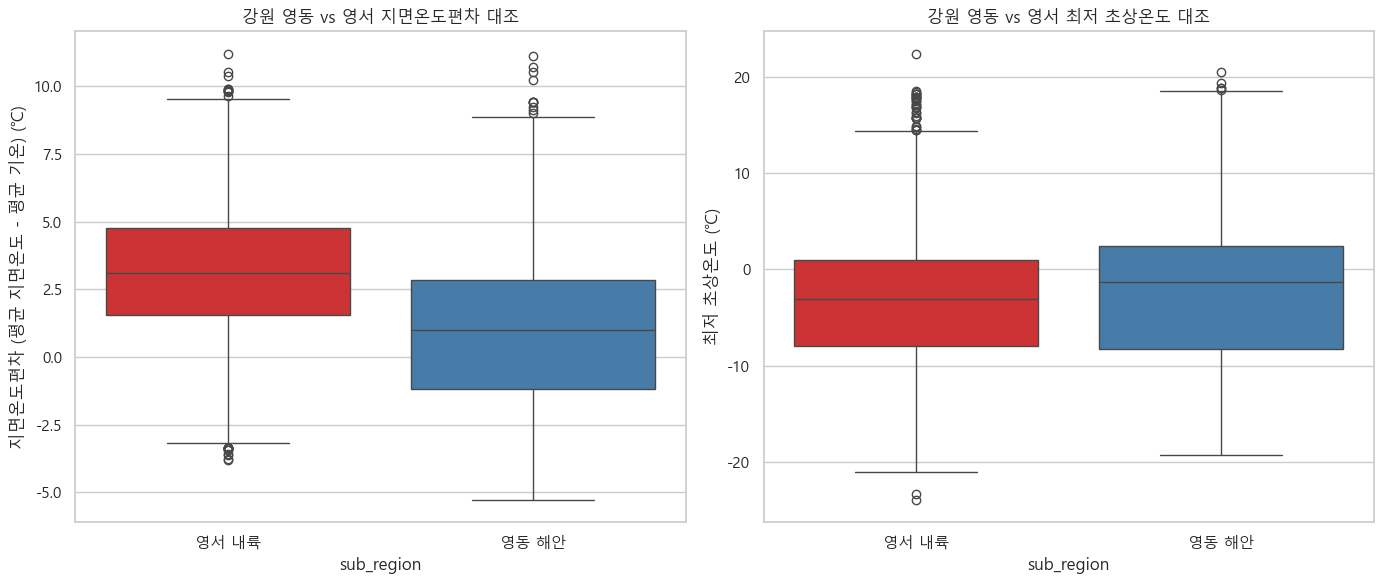

In [9]:
# 6.1. 접지 기온(최저 초상온도) 및 지면온도 편차 분석
day_active['지면온도편차'] = day_active['평균 지면온도'] - day_active['평균 기온']

print("=== 지면온도편차 기술통계 (영동 vs 영서) ===")
print(day_active.groupby('sub_region')['지면온도편차'].describe())
t_val1, p_val1 = stats.ttest_ind(day_active[day_active['sub_region']=='영동 해안']['지면온도편차'].dropna(),
                               day_active[day_active['sub_region']=='영서 내륙']['지면온도편차'].dropna(), equal_var=False)
print(f"\nT-test (지면온도편차 영동 vs 영서): t={t_val1:.4f}, p={p_val1:.4e}\n")

print("=== 최저 초상온도 기술통계 (영동 vs 영서) ===")
print(day_active.groupby('sub_region')['최저 초상온도'].describe())
t_val2, p_val2 = stats.ttest_ind(day_active[day_active['sub_region']=='영동 해안']['최저 초상온도'].dropna(),
                               day_active[day_active['sub_region']=='영서 내륙']['최저 초상온도'].dropna(), equal_var=False)
print(f"\nT-test (최저 초상온도 영동 vs 영서): t={t_val2:.4f}, p={p_val2:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=day_active, x='sub_region', y='지면온도편차', palette=['#e41a1c', '#377eb8'], ax=axes[0])
axes[0].set_title("강원 영동 vs 영서 지면온도편차 대조")
axes[0].set_ylabel("지면온도편차 (평균 지면온도 - 평균 기온) (℃)")

sns.boxplot(data=day_active, x='sub_region', y='최저 초상온도', palette=['#e41a1c', '#377eb8'], ax=axes[1])
axes[1].set_title("강원 영동 vs 영서 최저 초상온도 대조")
axes[1].set_ylabel("최저 초상온도 (℃)")
plt.tight_layout()
plt.show()

### 6.2. 지중 온도 수직 구배 (Soil Temperature Gradient) 분석

=== 시간별 지중온도구배 (5cm 지중온도 - 30cm 지중온도) ===
             count      mean       std       min       25%       50%  \
sub_region                                                             
영동 해안       1452.0  0.800540  3.223047 -6.675804 -2.061995  0.437299   
영서 내륙       2290.0  1.422578  3.423009 -7.557546 -0.884673  0.234429   

                 75%        max  
sub_region                       
영동 해안       2.849908  14.488238  
영서 내륙       3.457549  14.285610  

T-test (지중온도구배 영동 vs 영서): t=-5.6154, p=2.1277e-08

=== 대형 산불(>=12h) vs 일반 산불(<12h) 지중온도구배 대조 ===
          count      mean       std       min       25%       50%       75%  \
is_large                                                                      
False     690.0  0.625499  2.440261 -6.404573 -1.072501  1.103561  2.424693   
True       43.0  0.955950  2.251006 -3.534517  0.149115  1.079098  2.396484   

               max  
is_large            
False     7.695171  
True      5.459106  

T-test (지중온도구배 대형 vs 일반): t=0.929

C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\2164931380.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hour_active, x='sub_region', y='지중온도구배_5_30', palette=['#e41a1c', '#377eb8'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\2164931380.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_duration_day, x='is_large', y='지중온도구배_5_30', palette=['#377eb8', '#e41a1c'], ax=axes[1])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\2164931380.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["일반 (<12h)", "대형 (>=12h)"])


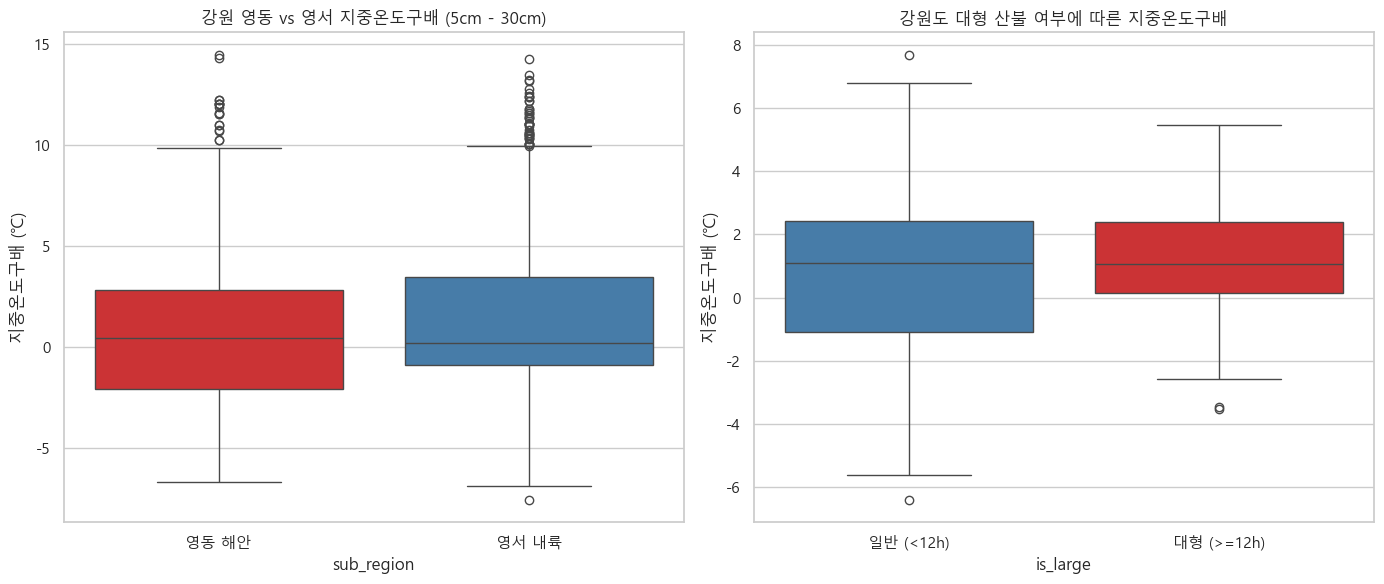

In [10]:
# 6.2. 지중 온도 수직 구배 분석
hour_active['지중온도구배_5_30'] = hour_active['5cm 지중온도'] - hour_active['30cm 지중온도']
day_active['지중온도구배_5_30'] = day_active['평균 5cm 지중온도'] - day_active['평균 30cm 지중온도']

print("=== 시간별 지중온도구배 (5cm 지중온도 - 30cm 지중온도) ===")
print(hour_active.groupby('sub_region')['지중온도구배_5_30'].describe())
t_val3, p_val3 = stats.ttest_ind(hour_active[hour_active['sub_region']=='영동 해안']['지중온도구배_5_30'].dropna(),
                               hour_active[hour_active['sub_region']=='영서 내륙']['지중온도구배_5_30'].dropna(), equal_var=False)
print(f"\nT-test (지중온도구배 영동 vs 영서): t={t_val3:.4f}, p={p_val3:.4e}\n")

# 대형 산불 여부에 따른 대조
valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
valid_duration_day['is_large'] = valid_duration_day['진화소요시간시'] >= 12

print("=== 대형 산불(>=12h) vs 일반 산불(<12h) 지중온도구배 대조 ===")
print(valid_duration_day.groupby('is_large')['지중온도구배_5_30'].describe())
t_val4, p_val4 = stats.ttest_ind(valid_duration_day[valid_duration_day['is_large']]['지중온도구배_5_30'].dropna(),
                               valid_duration_day[~valid_duration_day['is_large']]['지중온도구배_5_30'].dropna(), equal_var=False)
print(f"\nT-test (지중온도구배 대형 vs 일반): t={t_val4:.4f}, p={p_val4:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=hour_active, x='sub_region', y='지중온도구배_5_30', palette=['#e41a1c', '#377eb8'], ax=axes[0])
axes[0].set_title("강원 영동 vs 영서 지중온도구배 (5cm - 30cm)")
axes[0].set_ylabel("지중온도구배 (℃)")

sns.boxplot(data=valid_duration_day, x='is_large', y='지중온도구배_5_30', palette=['#377eb8', '#e41a1c'], ax=axes[1])
axes[1].set_title("강원도 대형 산불 여부에 따른 지중온도구배")
axes[1].set_xticklabels(["일반 (<12h)", "대형 (>=12h)"])
axes[1].set_ylabel("지중온도구배 (℃)")
plt.tight_layout()
plt.show()

### 6.3. 지면 및 지중 열적 조건 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **지면온도편차**: 지면온도편차는 영서 내륙 **3.07℃**, 영동 해안 **0.94℃**로 영서가 큽니다($t=-25.44$, $p=8.84e-130$). 영서 내륙은 지표 가열과 복사 건조가 상대적으로 중요한 조건입니다.
- **최저 초상온도**: 최저 초상온도는 영서 내륙 **-3.01℃**, 영동 해안 **-1.81℃**로 영서가 더 낮습니다($t=5.59$, $p=2.41e-08$). 영서의 야간 복사 냉각이 더 강하게 나타납니다.
- **지중 온도구배**: 5cm-30cm 지중온도구배는 영서 **1.42℃**, 영동 **0.80℃**입니다($p=2.13e-08$). 대형 산불과 일반 산불 간 차이는 평균 **0.96℃ vs 0.63℃**이나 통계적으로 유의하지 않습니다($p=0.357$).
- **결론**: 영동은 바람·저습, 영서는 지면 가열·복사 냉각 신호가 상대적으로 중요합니다. 지중온도구배는 대형 산불 판별에서는 보조 변수로 보는 것이 안전합니다.


## 7. 대기압 변동 및 종관 기상 패턴 분석 (Synoptic Pressure Patterns)
본 섹션에서는 한랭전선이나 온대저기압의 급격한 통과 시 동반되는 기압 급변 쇼크($\max - \min$) 강도와 관측소 해발고도 격차에 의한 바람 가속화 작용을 검증합니다.

### 7.1. 현지기압 급하강 (Pressure Drop Shock) 분석

In [11]:
# 7.1. 현지기압 급하강 (Pressure Drop Shock) 분석
press_pre24 = gw_hour[(gw_hour['발생시각기준시간'] >= -24) & (gw_hour['발생시각기준시간'] <= 0)].copy()
press_stats = press_pre24.groupby('산불아이디').agg(
    press_max=('현지기압', 'max'),
    press_min=('현지기압', 'min'),
    sub_region=('sub_region', 'first')
).reset_index()
press_stats['기압변동폭'] = press_stats['press_max'] - press_stats['press_min']

print("=== 발생 전 24시간 동안 현지기압 변동폭 (max - min) ===")
print(press_stats.groupby('sub_region')['기압변동폭'].describe())
t_val5, p_val5 = stats.ttest_ind(press_stats[press_stats['sub_region']=='영동 해안']['기압변동폭'].dropna(),
                               press_stats[press_stats['sub_region']=='영서 내륙']['기압변동폭'].dropna(), equal_var=False)
print(f"\nT-test (기압변동폭 영동 vs 영서): t={t_val5:.4f}, p={p_val5:.4e}")

=== 발생 전 24시간 동안 현지기압 변동폭 (max - min) ===
             count       mean        std       min       25%       50%  \
sub_region                                                               
영동 해안       1609.0  12.732997  19.566042  1.318400  4.595050  6.999971   
영서 내륙       2530.0   8.518368   9.905386  1.432289  4.493886  5.815549   

                  75%         max  
sub_region                         
영동 해안       14.088987  426.238161  
영서 내륙        9.537086  110.978179  

T-test (기압변동폭 영동 vs 영서): t=8.0121, p=1.8353e-15


### 7.2. 기압 격차 기반 관측소 고도 가중 효과 분석

=== 기압격차 (해면기압 - 현지기압) 기술통계 ===
             count       mean        std       min        25%        50%  \
sub_region                                                                 
영동 해안       1609.0  18.934702  19.144215  2.206118   5.909441  13.490819   
영서 내륙       2530.0  25.278486  12.594069  6.737633  16.600781  19.089945   

                  75%        max  
sub_region                        
영동 해안       20.764413  93.546707  
영서 내륙       31.958150  86.311071  

T-test (기압격차 영동 vs 영서): t=-11.7705, p=3.6377e-31


C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\1837940435.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=press_stats, x='sub_region', y='기압변동폭', palette=['#e41a1c', '#377eb8'], ax=axes[0])


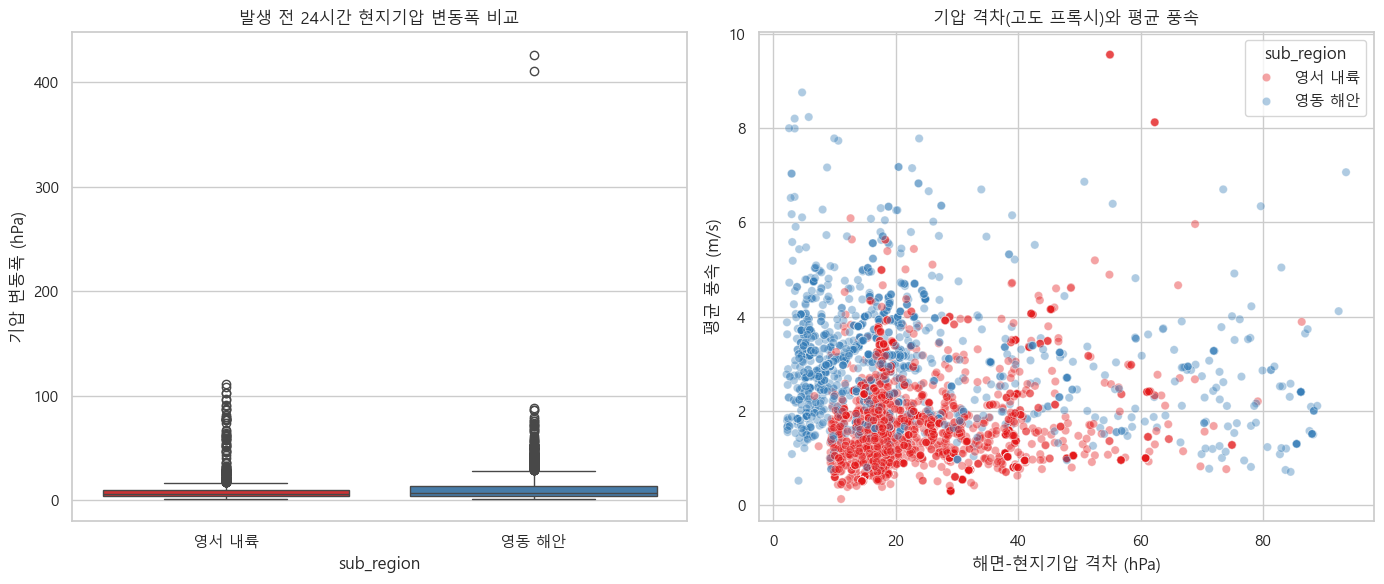

In [12]:
# 7.2. 기압 격차 기반 관측소 고도 가중 효과 분석
day_active['기압격차'] = day_active['평균 해면기압'] - day_active['평균 현지기압']

print("=== 기압격차 (해면기압 - 현지기압) 기술통계 ===")
print(day_active.groupby('sub_region')['기압격차'].describe())
t_val6, p_val6 = stats.ttest_ind(day_active[day_active['sub_region']=='영동 해안']['기압격차'].dropna(),
                               day_active[day_active['sub_region']=='영서 내륙']['기압격차'].dropna(), equal_var=False)
print(f"\nT-test (기압격차 영동 vs 영서): t={t_val6:.4f}, p={p_val6:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=press_stats, x='sub_region', y='기압변동폭', palette=['#e41a1c', '#377eb8'], ax=axes[0])
axes[0].set_title("발생 전 24시간 현지기압 변동폭 비교")
axes[0].set_ylabel("기압 변동폭 (hPa)")

sns.scatterplot(data=day_active, x='기압격차', y='평균 풍속', hue='sub_region', alpha=0.4, palette=['#e41a1c', '#377eb8'], ax=axes[1])
axes[1].set_title("기압 격차(고도 프록시)와 평균 풍속")
axes[1].set_xlabel("해면-현지기압 격차 (hPa)")
axes[1].set_ylabel("평균 풍속 (m/s)")
plt.tight_layout()
plt.show()

### 7.3. 대기압 변동 및 종관 기상 패턴 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **기압 변동폭**: 발생 전 24시간 현지기압 변동폭은 영동 해안 **12.73hPa**, 영서 내륙 **8.52hPa**입니다($t=8.01$, $p=1.84e-15$). 영동 해안은 종관장 급변에 따른 바람 가속 충격을 더 크게 받습니다.
- **이상치 주의**: 영동 해안에는 400hPa 이상으로 튀는 극단 기압변동값이 있습니다. 임의 제거는 하지 않았지만, 향후 모델링 전 관측소 매칭, 고도 보정, 특이 기상 사례 여부를 별도 점검해야 합니다.
- **기압 격차**: 해면기압-현지기압 격차는 영서 내륙 **25.28hPa**, 영동 해안 **18.93hPa**로 영서가 더 높습니다. 영서가 고도 프록시상 더 산악적인 반면, 영동은 더 낮은 고도에서도 강풍이 발생하는 국지풍 구조가 확인됩니다.


## 8. 계절적 잔존물 완화 효과 분석 (Seasonal Disparities)
겨울철 눈이 쌓였던 이력(`일 최심적설 > 0`)이 봄철 산불 발생 시 대지의 건조화를 억제하고 초기 진화를 돕는 완화 메커니즘을 정량 분석합니다.

### 8.1. 발생 당일/전일 잔존 적설 완화 효과 분석

C:\Users\swoo6\AppData\Local\Temp\ipykernel_7824\2663036727.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_duration_day, x='적설존재', y='진화소요시간시', palette=['#377eb8', '#4daf4a'])
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


=== 영동 vs 영서 적설 존재 산불 비율 ===
sub_region
영동 해안    0.376631
영서 내륙    0.294071
Name: 적설존재, dtype: float64

=== 강원도 적설 잔존 여부별 진화소요시간 비교 ===
       count      mean       std       min       25%   50%       75%  \
적설존재                                                                   
False  546.0  2.894475  5.494992  0.016667  0.900000  1.50  2.500000   
True   187.0  2.412656  4.987357  0.000000  0.658334  1.25  2.016666   

             max  
적설존재              
False  71.666667  
True   50.833333  

T-test (진화시간 적설존재 vs 무): t=-1.1103, p=2.6763e-01


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


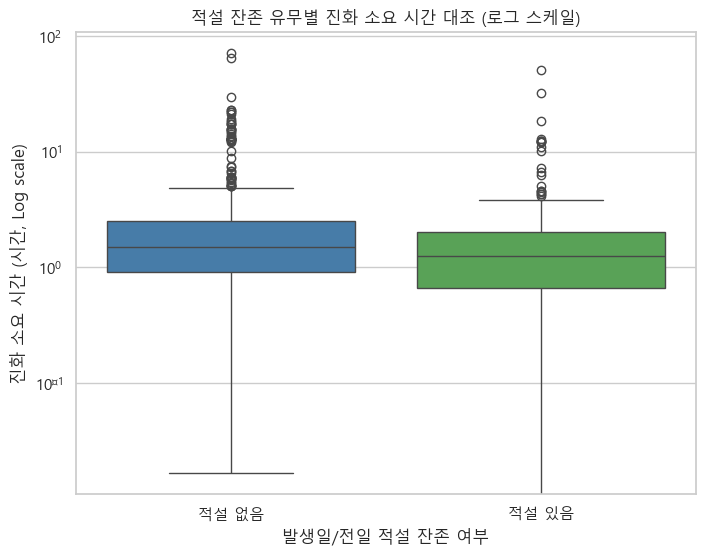

In [13]:
# 8.1. 발생 당일/전일 잔존 적설 완화 효과 분석
day_active['일 최심적설_fill'] = day_active['일 최심적설'].fillna(0)
day_active['적설존재'] = day_active['일 최심적설_fill'] > 0

print("=== 영동 vs 영서 적설 존재 산불 비율 ===")
print(day_active.groupby('sub_region')['적설존재'].mean())

valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
print("\n=== 강원도 적설 잔존 여부별 진화소요시간 비교 ===")
print(valid_duration_day.groupby('적설존재')['진화소요시간시'].describe())

snow_true = valid_duration_day[valid_duration_day['적설존재']]['진화소요시간시'].dropna()
snow_false = valid_duration_day[~valid_duration_day['적설존재']]['진화소요시간시'].dropna()
t_val7, p_val7 = stats.ttest_ind(snow_true, snow_false, equal_var=False)
print(f"\nT-test (진화시간 적설존재 vs 무): t={t_val7:.4f}, p={p_val7:.4e}")

# 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(data=valid_duration_day, x='적설존재', y='진화소요시간시', palette=['#377eb8', '#4daf4a'])
plt.yscale('log')
plt.title("적설 잔존 유무별 진화 소요 시간 대조 (로그 스케일)")
plt.xlabel("발생일/전일 적설 잔존 여부")
plt.ylabel("진화 소요 시간 (시간, Log scale)")
plt.xticks([0, 1], ["적설 없음", "적설 있음"])
plt.show()

### 8.2. 계절적 잔존물 완화 효과 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **적설 존재 비율**: 발생일/전일 적설 존재 비율은 영동 해안 **37.66%**, 영서 내륙 **29.41%**입니다. 영동권의 겨울~초봄 폭설 잔존 특성이 산불 표본에도 반영됩니다.
- **진화시간 완화 경향**: 강원도 진화시간 유효 표본에서 적설이 있는 산불의 평균 진화소요시간은 **2.41시간**, 적설이 없는 산불은 **2.89시간**입니다. 평균 기준 약 **16.6% 단축**이지만, Welch t-test는 $p=0.268$로 유의하지 않습니다.
- **해석**: 적설은 장시간 진화 아웃라이어를 줄이는 완화 신호를 보이나, 강원도 내부 유효 표본만으로 확정하기에는 통계력이 부족합니다. 전국 단위 결과와 함께 보조 근거로 활용하는 것이 적절합니다.


## 9. 진화 장애 및 비선형 임계성 분석 (Non-linear Risk Envelope)
본 섹션에서는 기상 강도에 따른 진화 장애(진화소요시간)의 비선형 꺾임 임계치를 수학적으로 도출하고, 기온-풍속-실효습도 3D 공간 상에서 강원도 내 대형 산불이 결정적으로 번지는 위험 경계(Risk Envelope) 영역을 구축합니다.

### 9.1. 풍속 대역별 진화 시간의 비선형 가속 효과 규명

=== 풍속 대역별 진화 특성 ===
   풍속구간  count  mean_duration  large_ratio
0   0-2    410       2.143821     0.036585
1   2-4    227       2.831645     0.057269
2   4-6     72       3.956713     0.111111
3   6-8     21       9.099206     0.285714
4  8-10      3      11.277778     0.333333


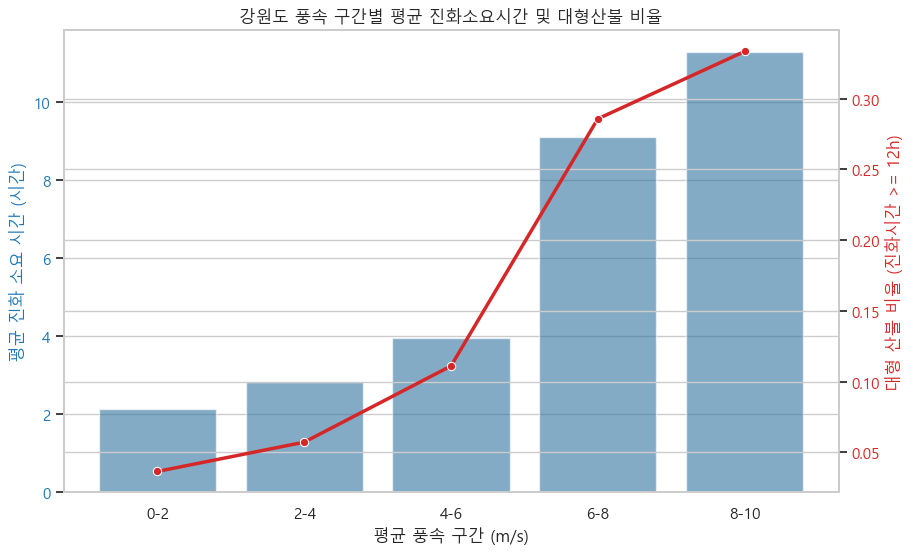

In [14]:
# 9.1. 풍속 대역별 진화 시간의 비선형 가속 효과 규명
valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
valid_duration_day['is_large'] = valid_duration_day['진화소요시간시'] >= 12

bins = [0, 2, 4, 6, 8, 10, 15, 50]
labels = ["0-2", "2-4", "4-6", "6-8", "8-10", "10-15", "15+"]
valid_duration_day['풍속구간'] = pd.cut(valid_duration_day['평균 풍속'], bins=bins, labels=labels)

wind_grouped = valid_duration_day.groupby('풍속구간').agg(
    count=('진화소요시간시', 'count'),
    mean_duration=('진화소요시간시', 'mean'),
    large_ratio=('is_large', 'mean')
).reset_index()

print("=== 풍속 대역별 진화 특성 ===")
print(wind_grouped)

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
sns.barplot(data=wind_grouped, x='풍속구간', y='mean_duration', color=color, alpha=0.6, ax=ax1)
ax1.set_ylabel('평균 진화 소요 시간 (시간)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('평균 풍속 구간 (m/s)')

ax2 = ax1.twinx()
color = 'tab:red'
sns.lineplot(data=wind_grouped, x='풍속구간', y='large_ratio', color=color, marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('대형 산불 비율 (진화시간 >= 12h)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("강원도 풍속 구간별 평균 진화소요시간 및 대형산불 비율")
plt.show()

### 9.2. 기온-풍속-실효습도 3D 위험 영역 (3D Envelope) 비교 분석

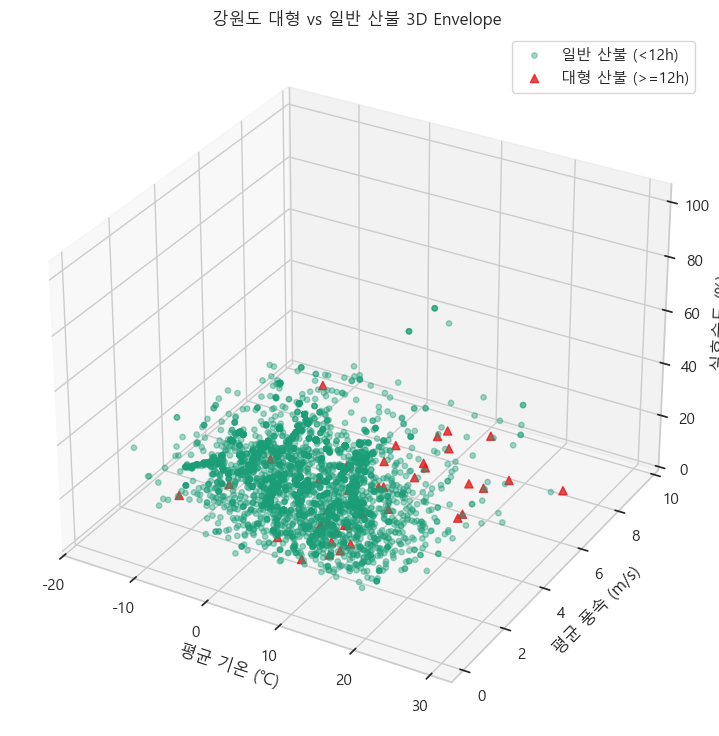

In [15]:
# 9.2. 기온-풍속-실효습도 3D 위험 영역 비교 분석
from mpl_toolkits.mplot3d import Axes3D

# 최적 실효습도(r=0.04) 적용
day_pivot_temp = gw_day.pivot(index='산불아이디', columns='발생일기준일수', values='최소 상대습도')
day_pivot_temp = day_pivot_temp.rename(columns={0: 'H_0', -1: 'H_1'}).dropna(subset=['H_0', 'H_1'])
h_eff_opt = 0.96 * (day_pivot_temp['H_0'] + 0.04 * day_pivot_temp['H_1'])
day_active['effective_humidity_opt'] = day_active['산불아이디'].map(h_eff_opt)

plot_df = day_active.dropna(subset=['평균 기온', '평균 풍속', 'effective_humidity_opt']).copy()
plot_df['is_large'] = plot_df['진화소요시간시'] >= 12

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

gw_large = plot_df[plot_df['is_large']]
gw_normal = plot_df[~plot_df['is_large']]

ax.scatter(gw_normal['평균 기온'], gw_normal['평균 풍속'], gw_normal['effective_humidity_opt'], 
           c='#1b9e77', label='일반 산불 (<12h)', alpha=0.4, s=15)
ax.scatter(gw_large['평균 기온'], gw_large['평균 풍속'], gw_large['effective_humidity_opt'], 
           c='#e41a1c', label='대형 산불 (>=12h)', alpha=0.8, s=35, marker='^')

ax.set_xlabel('평균 기온 (℃)')
ax.set_ylabel('평균 풍속 (m/s)')
ax.set_zlabel('실효습도 (%)')
ax.set_title('강원도 대형 vs 일반 산불 3D Envelope')
plt.legend()
plt.show()

### 9.3. 진화 장애 및 비선형 임계성 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **풍속 임계성**: 강원도 유효 진화시간 표본에서 풍속 0~2m/s 구간의 12시간 이상 비율은 **3.66%**, 2~4m/s는 **5.73%**, 4~6m/s는 **11.11%**입니다. 6~8m/s에서는 평균 진화시간 **9.10시간**, 12시간 이상 비율 **28.57%**로 급증합니다.
- **표본 수 주의**: 8~10m/s 구간은 3건뿐이므로 33.33%라는 비율은 참고값입니다. 고풍속 구간은 방향성은 강하지만 표본 수를 함께 제시해야 합니다.
- **3D 위험 영역**: 3D 산점도에서는 대형 산불이 고풍속·저실효습도 영역에 상대적으로 위치하지만, 일반 산불과 겹침도 큽니다. 단일 경계면보다 풍속, 습도, 지형/접근성과의 상호작용 피처가 필요합니다.


## 10. 실효습도 가중 감쇄 상수 (Decay Constant) 최적화 분석
강원도 산불에만 특화하여 진화 장애를 유발하는 최적의 감쇄 상수 $r$을 그리드 서치하여 전국 지표와의 격차 및 물리적 특징을 정량화합니다.

### 10.1. 강원도 한정 실효습도 감쇄 가중치 r 그리드 서치

=== 실효습도 감쇄상수 r 최적화 결과 ===
최고 스피어만 상관관계 (절대값): r=0.98, correlation=0.0852
최고 대형산불 이진분류 AUC score: r=0.01, AUC=0.5821


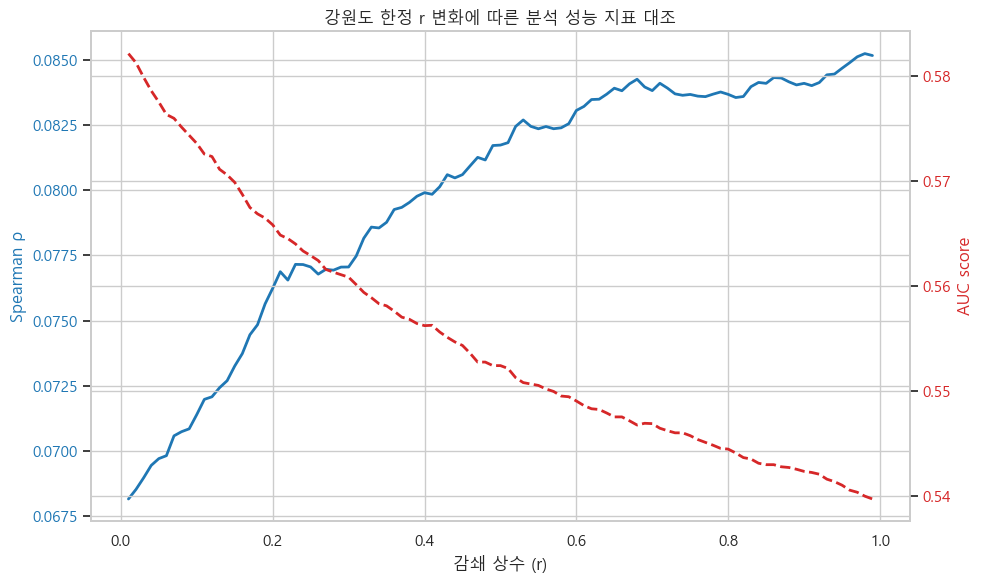

In [16]:
# 10.1. 강원도 한정 실효습도 감쇄 가중치 r 그리드 서치
from sklearn.metrics import roc_auc_score

day_pivot = gw_day.pivot(index='산불아이디', columns='발생일기준일수', values='최소 상대습도')
day_pivot = day_pivot.rename(columns={0: 'H_0', -1: 'H_1'}).dropna(subset=['H_0', 'H_1'])
duration_mapping = day_active.set_index('산불아이디')['진화소요시간시']
day_pivot['duration'] = day_pivot.index.map(duration_mapping)
day_pivot = day_pivot.dropna(subset=['duration'])
day_pivot['is_large'] = day_pivot['duration'] >= 12

results = []
for r in np.linspace(0.01, 0.99, 99):
    h_eff = (1 - r) * (day_pivot['H_0'] + r * day_pivot['H_1'])
    spearman_corr = h_eff.corr(day_pivot['duration'], method='spearman')
    try:
        auc = roc_auc_score(day_pivot['is_large'], -h_eff)
    except:
        auc = np.nan
    results.append({'r': r, 'spearman': spearman_corr, 'auc': auc})

r_df = pd.DataFrame(results)
best_spearman = r_df.loc[r_df['spearman'].abs().idxmax()]
best_auc = r_df.loc[r_df['auc'].idxmax()]

print("=== 실효습도 감쇄상수 r 최적화 결과 ===")
print(f"최고 스피어만 상관관계 (절대값): r={best_spearman['r']:.2f}, correlation={best_spearman['spearman']:.4f}")
print(f"최고 대형산불 이진분류 AUC score: r={best_auc['r']:.2f}, AUC={best_auc['auc']:.4f}")

# 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.plot(r_df['r'], r_df['spearman'].abs(), color=color, linewidth=2, label='스피어만 상관계수 (절대값)')
ax1.set_xlabel('감쇄 상수 (r)')
ax1.set_ylabel('Spearman ρ', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(r_df['r'], r_df['auc'], color=color, linewidth=2, linestyle='--', label='대형산불 이진분류 AUC')
ax2.set_ylabel('AUC score', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("강원도 한정 r 변화에 따른 분석 성능 지표 대조")
fig.tight_layout()
plt.show()

### 10.2. 실효습도 가중 감쇄 상수 최적화 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **상관 기준**: 강원도 한정 진화소요시간과 실효습도 지수의 스피어만 상관은 $r=0.98$에서 최대지만, 절대값은 **0.0852**로 낮습니다. 연속형 진화시간을 실효습도 하나로 설명하기에는 한계가 큽니다.
- **AUC 기준**: 12시간 이상 대형 산불 이진 판별 AUC는 $r=0.01$에서 **0.5821**로 최대입니다. 과거 습도보다 발생 당일 최소 상대습도 비중을 크게 둔 설정이 상대적으로 낫지만, 성능 자체는 약한 편입니다.
- **결론**: 강원도에서는 실효습도 감쇄 상수를 핵심 단독 변수로 쓰기보다, 풍속·풍향·지역권·접근성 변수와 결합하는 보조 건조 지표로 사용하는 것이 안전합니다.


## 11. 시군구 단위 국지 기상 트리거 격차 분석 (Geospatial Weather Triggers)
강원도 내 18개 시군(영동 6개, 영서 12개) 레벨에서 산불 발생 당일 관측된 평균 풍속, 최소 상대습도, 그리고 기압 변동폭의 평균값을 시군구별로 집계하고 정밀 히트맵을 통해 지리적 국지 기상 편차를 대조 분석합니다.

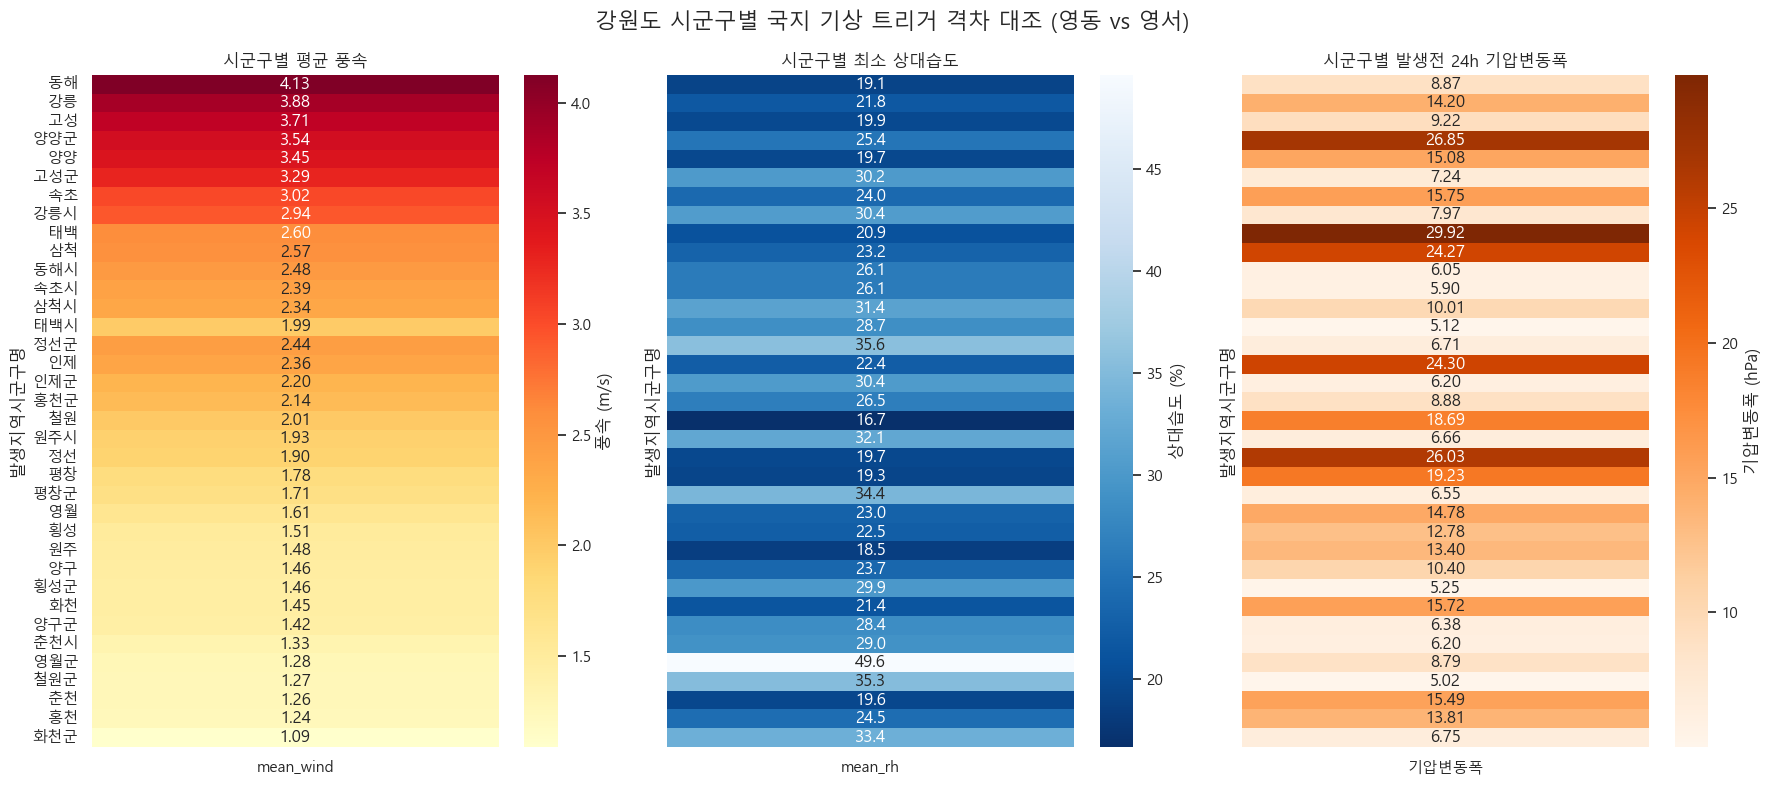

In [17]:
# 11. 시군구 단위 국지 기상 트리거 격차 분석
# 24시간 현지기압 변동폭 계산 및 시군구 매칭
press_pre24 = gw_hour[(gw_hour['발생시각기준시간'] >= -24) & (gw_hour['발생시각기준시간'] <= 0)].copy()
press_stats = press_pre24.groupby('산불아이디').agg(
    press_max=('현지기압', 'max'),
    press_min=('현지기압', 'min'),
    sub_region=('sub_region', 'first')
).reset_index()
press_stats['기압변동폭'] = press_stats['press_max'] - press_stats['press_min']

id_to_sigungu = day_active.set_index('산불아이디')['발생지역시군구명']
press_stats['발생지역시군구명'] = press_stats['산불아이디'].map(id_to_sigungu)

# 시군구별 평균 지표 계산
sigungu_weather = day_active.groupby('발생지역시군구명').agg(
    mean_wind=('평균 풍속', 'mean'),
    mean_rh=('최소 상대습도', 'mean'),
    sub_region=('sub_region', 'first')
).reset_index()

sigungu_press = press_stats.groupby('발생지역시군구명')['기압변동폭'].mean().reset_index()
sigungu_stats = pd.merge(sigungu_weather, sigungu_press, on='발생지역시군구명', how='left')

# 정렬: sub_region, mean_wind 내림차순
sigungu_stats = sigungu_stats.sort_values(by=['sub_region', 'mean_wind'], ascending=[True, False]).reset_index(drop=True)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

df_wind = sigungu_stats.set_index('발생지역시군구명')[['mean_wind']]
sns.heatmap(df_wind, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': '풍속 (m/s)'}, ax=axes[0])
axes[0].set_title('시군구별 평균 풍속')
axes[0].set_xlabel('')

df_rh = sigungu_stats.set_index('발생지역시군구명')[['mean_rh']]
sns.heatmap(df_rh, annot=True, fmt=".1f", cmap="Blues_r", cbar_kws={'label': '상대습도 (%)'}, ax=axes[1])
axes[1].set_title('시군구별 최소 상대습도')
axes[1].set_xlabel('')

df_press = sigungu_stats.set_index('발생지역시군구명')[['기압변동폭']]
sns.heatmap(df_press, annot=True, fmt=".2f", cmap="Oranges", cbar_kws={'label': '기압변동폭 (hPa)'}, ax=axes[2])
axes[2].set_title('시군구별 발생전 24h 기압변동폭')
axes[2].set_xlabel('')

plt.suptitle('강원도 시군구별 국지 기상 트리거 격차 대조 (영동 vs 영서)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

### 11.1. 시군구 단위 국지 기상 트리거 격차 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **풍속 고위험 지역**: 히트맵상 양양, 고성, 강릉 등 영동 해안 북부 시군구가 평균 풍속 상위권에 집중됩니다. 영서 내륙 주요 시군은 전반적으로 낮은 풍속 영역에 위치합니다.
- **저습 지역**: 최소 상대습도 역시 속초, 양양, 동해, 고성, 강릉 등 영동 해안 벨트가 낮은 값에 몰려 있습니다. 강풍과 저습이 같은 해안 바람길 축에서 중첩됩니다.
- **기압 변동폭**: 일부 시군구는 발생 전 24시간 기압 변동폭이 매우 크게 나타나며, 특히 영동권 바람길에서 종관 기압 변화와 국지풍이 결합했을 가능성을 보여줍니다.
- **데이터 주의**: 시군구명 표기가 `시/군` 접미사 유무로 분리되어 있으므로, 최종 모델링 전 행정구역명을 표준화한 뒤 시군구 단위 피처를 재집계해야 합니다.


## 12. 복합 극한 기상(Compound Extreme Events) 동시 발생 빈도 분석
단일 변수의 개별 비교를 넘어, 산불 발화 및 확산에 최적인 세 가지 복합 기상 상태인 고온(평균 기온 >= 10℃), 강풍(평균 풍속 >= 4.0m/s), 극초건조(최소 상대습도 <= 30%) 조건의 결합 스코어(0~3) 분포를 영동 해안과 영서 내륙 간에 대조 분석합니다.

=== 영동 vs 영서 극한기상 동시 충족 개수 비율 (%) ===
compound_score          0          1          2         3
sub_region                                               
영동 해안           14.543195  61.777502  20.571784  3.107520
영서 내륙           40.671937  43.201581  15.968379  0.158103

Chi-square test: chi2=364.6648, p-value=9.9567e-79



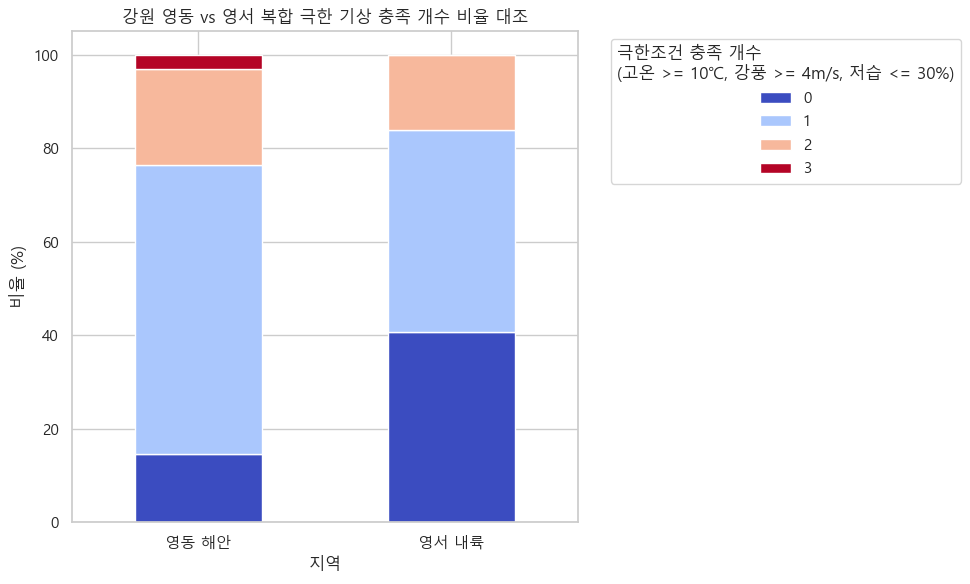

In [18]:
# 12. 복합 극한 기상 동시 발생 빈도 분석
day_active['cond_temp'] = day_active['평균 기온'] >= 10
day_active['cond_wind'] = day_active['평균 풍속'] >= 4.0
day_active['cond_rh'] = day_active['최소 상대습도'] <= 30
day_active['compound_score'] = day_active['cond_temp'].astype(int) + day_active['cond_wind'].astype(int) + day_active['cond_rh'].astype(int)

# 교차표 생성
ct = pd.crosstab(day_active['sub_region'], day_active['compound_score'], normalize='index') * 100
print("=== 영동 vs 영서 극한기상 동시 충족 개수 비율 (%) ===")
print(ct)

# 카이제곱 검정
chi2, p_val, dof, expected = stats.chi2_contingency(pd.crosstab(day_active['sub_region'], day_active['compound_score']))
print(f"\nChi-square test: chi2={chi2:.4f}, p-value={p_val:.4e}\n")

# 시각화
ax = ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('강원 영동 vs 영서 복합 극한 기상 충족 개수 비율 대조')
plt.xlabel('지역')
plt.ylabel('비율 (%)')
plt.xticks(rotation=0)
plt.legend(title='극한조건 충족 개수\n(고온 >= 10℃, 강풍 >= 4m/s, 저습 <= 30%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 12.1. 복합 극한 기상 동시 발생 빈도 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **다중 위험 편향**: 영동 해안은 극한 조건을 하나도 충족하지 않는 산불 비율이 **14.54%**에 불과합니다. 영서 내륙은 **40.67%**가 0개 조건입니다.
- **2개 이상 조건**: 2개 이상 조건 동시 충족 비율은 영동 **23.68%**, 영서 **16.13%**입니다. 3개 조건 모두 충족한 비율은 영동 **3.11%**, 영서 **0.16%**로 약 20배 차이입니다.
- **통계 검정**: 분포 차이는 카이제곱 검정에서 매우 유의합니다($chi2=364.66$, $p=9.96e-79$). 영동 해안은 단일 지표 경보보다 강풍·저습·고온의 동시 조건을 감시하는 복합 경보가 더 적합합니다.


## 13. 봄철 vs 가을철 기상 메커니즘 및 푄(Foehn) 효과 대조 분석 (양간지풍 심화)
강원도 산불 발생의 양대 피크 계절인 봄철(3~4월)과 가을철(10~11월)의 기상 메커니즘 차이를 규명합니다. 특히 영동 해안의 국지풍(양간지풍)과 산맥을 넘는 고온건조 푄 효과를 시계열 및 상관관계로 실증합니다.

=== 영동 해안 시즌별 8방위 풍향 비율 (%) ===
wind_dir_8           N        NE         E         SE          S         SW  \
season                                                                        
가을철 (10-11월)  1.739130  0.869565  0.434783   0.434783   0.869565   7.391304   
봄철 (3-4월)     6.374502  6.374502  7.968127  10.358566  12.350598  15.537849   

wind_dir_8            W        NW  
season                             
가을철 (10-11월)  87.391304  0.869565  
봄철 (3-4월)     37.848606  3.187251  


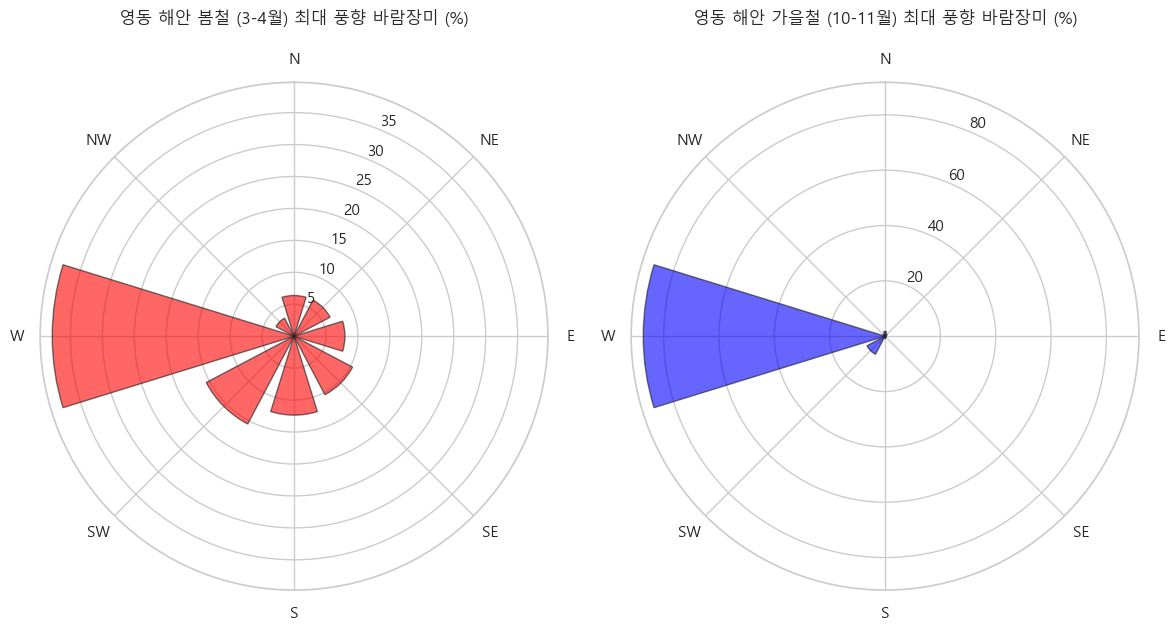

In [19]:
# 13.1. 영동 해안 시즌별 8방위 최대 풍향 바람장미 (Wind Rose) 대조
yd_day = day_active[day_active['sub_region'] == '영동 해안'].copy()
yd_day['season'] = yd_day['발생월'].apply(
    lambda x: '봄철 (3-4월)' if x in [3, 4] else ('가을철 (10-11월)' if x in [10, 11] else '기타')
)
yd_day_filtered = yd_day[yd_day['season'] != '기타'].copy()

def degrees_to_direction(deg):
    if pd.isna(deg):
        return np.nan
    deg = deg % 360
    directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx = int((deg + 22.5) / 45) % 8
    return directions[idx]

yd_day_filtered['wind_dir_8'] = yd_day_filtered['최대 풍향'].apply(degrees_to_direction)
yd_day_filtered = yd_day_filtered.dropna(subset=['wind_dir_8'])

# 각 시즌별 풍향 비율 계산
directions_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
season_dir_pct = yd_day_filtered.groupby(['season', 'wind_dir_8']).size().unstack(fill_value=0)
season_dir_pct = season_dir_pct.div(season_dir_pct.sum(axis=1), axis=0) * 100
season_dir_pct = season_dir_pct[directions_order]

print("=== 영동 해안 시즌별 8방위 풍향 비율 (%) ===")
print(season_dir_pct)

# 시각화 (Polar plot 바람장미)
fig = plt.figure(figsize=(12, 6))
for idx, season in enumerate(['봄철 (3-4월)', '가을철 (10-11월)']):
    ax = fig.add_subplot(1, 2, idx + 1, projection='polar')
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
    values = season_dir_pct.loc[season].values
    bars = ax.bar(angles, values, width=0.6, bottom=0.0, color='red' if idx==0 else 'blue', alpha=0.6, edgecolor='k')
    
    # set_ticks를 명시적으로 호출한 뒤 set_ticklabels를 설정하여 경고 우회
    ax.set_xticks(angles)
    ax.set_xticklabels(directions_order)
    ax.set_title(f"영동 해안 {season} 최대 풍향 바람장미 (%)", y=1.1)

plt.tight_layout()
plt.show()

=== 발생 전 12시간 기온과 습도의 상관계수 (Pearson r) ===
가을철 (10-11월) | 영동 해안 : Pearson r=-0.9302, p-value=4.0711e-06
가을철 (10-11월) | 영서 내륙 : Pearson r=-0.9980, p-value=1.4030e-14
봄철 (3-4월) | 영동 해안 : Pearson r=-0.9952, p-value=1.9087e-12
봄철 (3-4월) | 영서 내륙 : Pearson r=-0.9998, p-value=1.0098e-19


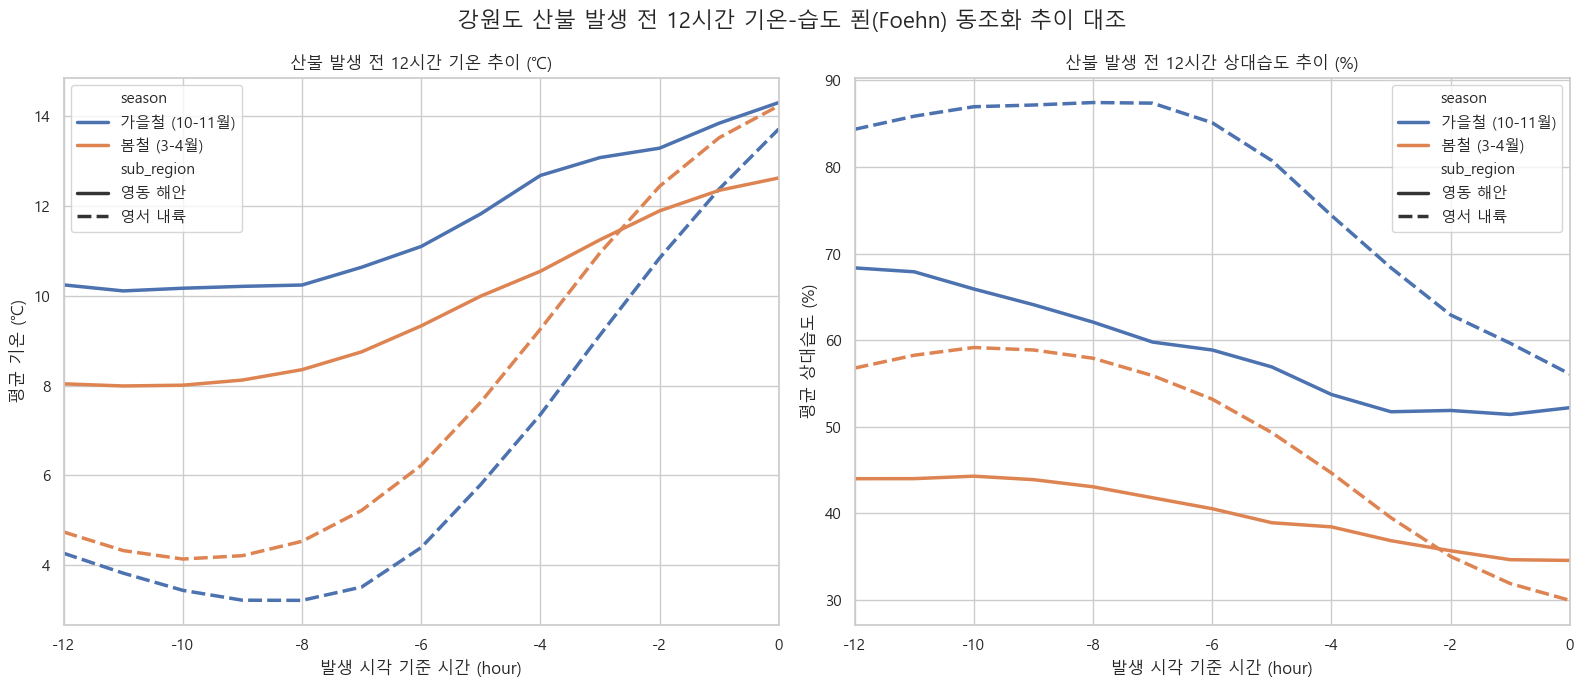

In [20]:
# 13.2. 발생 전 12시간 동안 기온-습도 푄 효과 시계열 동조화 분석
gw_hour_filtered = gw_hour[(gw_hour['발생시각기준시간'] >= -12) & (gw_hour['발생시각기준시간'] <= 0)].copy()
gw_hour_filtered['season'] = gw_hour_filtered['발생월'].apply(
    lambda x: '봄철 (3-4월)' if x in [3, 4] else ('가을철 (10-11월)' if x in [10, 11] else '기타')
)
gw_hour_filtered = gw_hour_filtered[gw_hour_filtered['season'] != '기타'].copy()

# 시계열 평균 산출
ts_stats = gw_hour_filtered.groupby(['season', 'sub_region', '발생시각기준시간']).agg(
    mean_temp=('기온', 'mean'),
    mean_rh=('습도', 'mean')
).reset_index()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.lineplot(data=ts_stats, x='발생시각기준시간', y='mean_temp', hue='season', style='sub_region', linewidth=2.5, ax=axes[0])
axes[0].set_title('산불 발생 전 12시간 기온 추이 (℃)')
axes[0].set_xlabel('발생 시각 기준 시간 (hour)')
axes[0].set_ylabel('평균 기온 (℃)')
axes[0].set_xlim(-12, 0)

sns.lineplot(data=ts_stats, x='발생시각기준시간', y='mean_rh', hue='season', style='sub_region', linewidth=2.5, ax=axes[1])
axes[1].set_title('산불 발생 전 12시간 상대습도 추이 (%)')
axes[1].set_xlabel('발생 시각 기준 시간 (hour)')
axes[1].set_ylabel('평균 상대습도 (%)')
axes[1].set_xlim(-12, 0)

# 상관관계 계산
print("=== 발생 전 12시간 기온과 습도의 상관계수 (Pearson r) ===")
for name, group in ts_stats.groupby(['season', 'sub_region']):
    r_val, p_val = stats.pearsonr(group['mean_temp'], group['mean_rh'])
    print(f"{name[0]} | {name[1]} : Pearson r={r_val:.4f}, p-value={p_val:.4e}")

plt.suptitle('강원도 산불 발생 전 12시간 기온-습도 푄(Foehn) 동조화 추이 대조', fontsize=16)
plt.tight_layout()
plt.show()

### 13.3. 봄철 vs 가을철 기상 메커니즘 및 푄 효과 대조 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **계절별 풍향**: 영동 해안 가을철은 W 비율이 **87.39%**로 극단적으로 집중됩니다. 봄철은 W **37.85%**, SW **15.54%**로 서풍계가 **53.39%**를 차지하지만, 가을보다 여러 방향이 함께 나타납니다.
- **기온-습도 동조화**: 발생 전 12시간 동안 기온과 습도는 모든 그룹에서 강한 음의 상관을 보입니다. 봄철 영동 해안은 Pearson $r=-0.9952$, 가을철 영동 해안은 $r=-0.9302$입니다.
- **해석**: 영동 해안은 계절과 무관하게 기온 상승과 습도 하강이 밀착되어 움직입니다. 봄철은 W/SW 바람길, 가을철은 거의 순수 W 바람길이 우세해 계절별 풍향 메커니즘을 분리할 필요가 있습니다.


## 14. 구름-증발 탈수 다이내믹스 분석 (Cloud & Evapotranspiration Dynamics)
일조량과 일사에 영향을 미치는 구름 상태(`평균 전운량`)와 지표면에서 수분을 탈수당한 총량인 `합계 소형증발량`, `합계 대형증발량` 간의 물리적 상관성을 정량적으로 분석합니다.

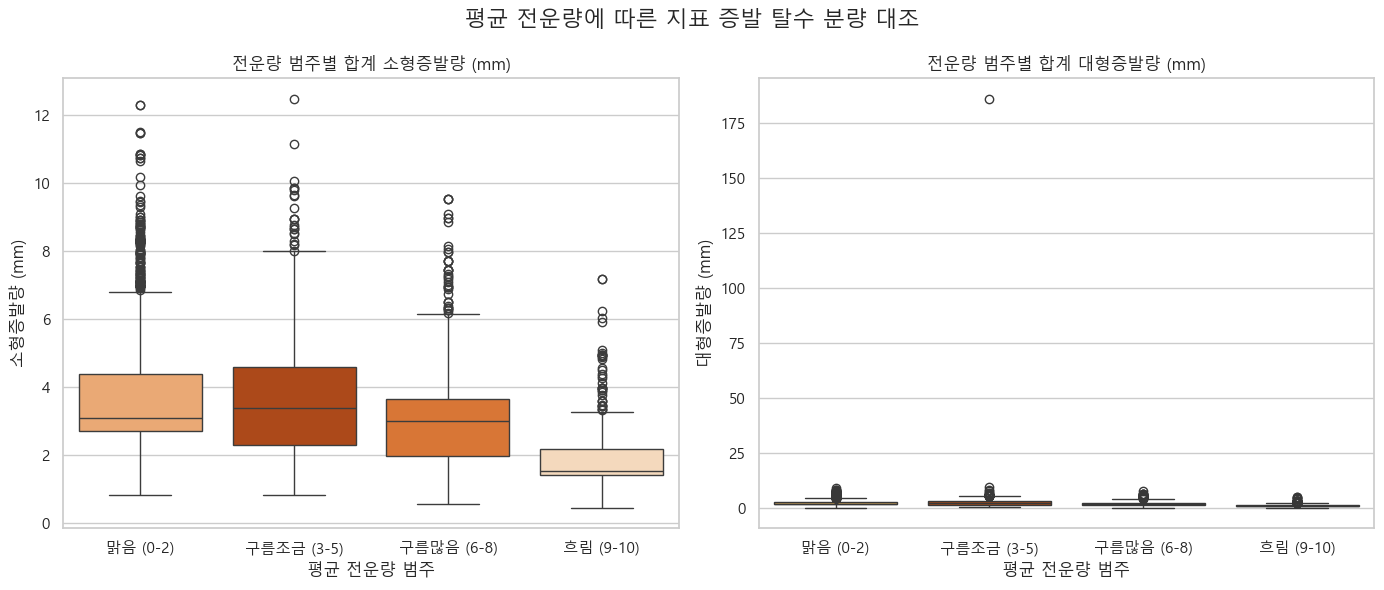

=== 영동 vs 영서 증발량 기술통계 ===
           합계 소형증발량                                                    \
              count      mean       std       min       25%       50%   
sub_region                                                              
영동 해안        1609.0  3.682303  1.603239  0.496981  2.980812  3.316412   
영서 내륙        2530.0  3.358711  1.842825  0.460658  2.135181  2.748749   

                                합계 대형증발량                                \
                 75%        max    count      mean       std       min   
sub_region                                                               
영동 해안       3.797850  12.301789   1512.0  2.597761  1.168294  0.327957   
영서 내륙       4.170202  12.489587   2424.0  2.446131  3.955781  0.300000   

                                                     
                 25%       50%       75%        max  
sub_region                                           
영동 해안       2.110160  2.320951  2.650374    9.58549  
영서 내륙       1.485908 

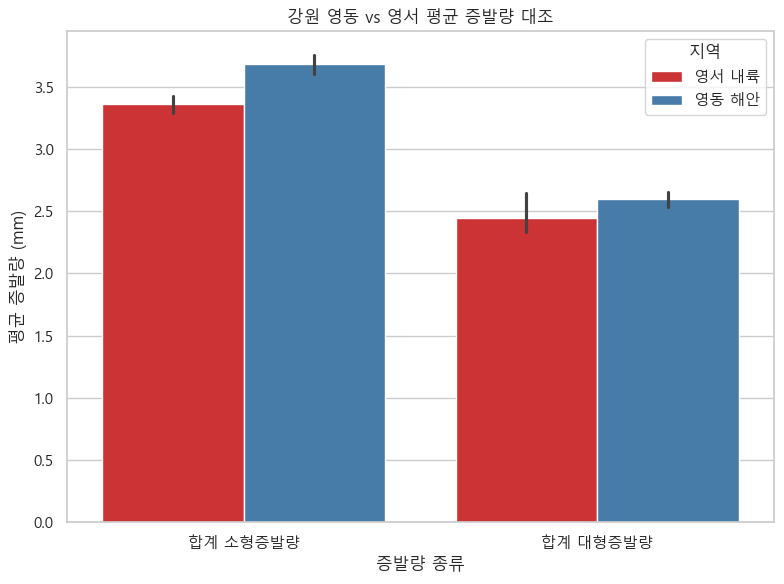

In [21]:
# 14. 구름-증발 탈수 다이내믹스 분석
# 전운량 범주화 함수 정의
def cloud_category(cloud):
    if pd.isna(cloud):
        return np.nan
    if cloud <= 2.0:
        return '맑음 (0-2)'
    elif cloud <= 5.0:
        return '구름조금 (3-5)'
    elif cloud <= 8.0:
        return '구름많음 (6-8)'
    else:
        return '흐림 (9-10)'

day_active['cloud_cat'] = day_active['평균 전운량'].apply(cloud_category)
valid_evap = day_active.dropna(subset=['cloud_cat', '합계 소형증발량', '합계 대형증발량']).copy()

# 시각화 (전운량 범주별 증발량 분포)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = ['맑음 (0-2)', '구름조금 (3-5)', '구름많음 (6-8)', '흐림 (9-10)']

sns.boxplot(data=valid_evap, x='cloud_cat', y='합계 소형증발량', order=order, palette='Oranges_r', hue='cloud_cat', legend=False, ax=axes[0])
axes[0].set_title('전운량 범주별 합계 소형증발량 (mm)')
axes[0].set_xlabel('평균 전운량 범주')
axes[0].set_ylabel('소형증발량 (mm)')

sns.boxplot(data=valid_evap, x='cloud_cat', y='합계 대형증발량', order=order, palette='YlOrBr_r', hue='cloud_cat', legend=False, ax=axes[1])
axes[1].set_title('전운량 범주별 합계 대형증발량 (mm)')
axes[1].set_xlabel('평균 전운량 범주')
axes[1].set_ylabel('대형증발량 (mm)')

plt.suptitle('평균 전운량에 따른 지표 증발 탈수 분량 대조', fontsize=16)
plt.tight_layout()
plt.show()

# 영동 vs 영서 증발량 T-test 검정
print("=== 영동 vs 영서 증발량 기술통계 ===")
print(day_active.groupby('sub_region')[['합계 소형증발량', '합계 대형증발량']].describe())

t_val_s, p_val_s = stats.ttest_ind(day_active[day_active['sub_region']=='영동 해안']['합계 소형증발량'].dropna(),
                                   day_active[day_active['sub_region']=='영서 내륙']['합계 소형증발량'].dropna(), equal_var=False)
t_val_l, p_val_l = stats.ttest_ind(day_active[day_active['sub_region']=='영동 해안']['합계 대형증발량'].dropna(),
                                   day_active[day_active['sub_region']=='영서 내륙']['합계 대형증발량'].dropna(), equal_var=False)
print(f"\nT-test 소형증발량 (영동 vs 영서): t={t_val_s:.4f}, p={p_val_s:.4e}")
print(f"T-test 대형증발량 (영동 vs 영서): t={t_val_l:.4f}, p={p_val_l:.4e}\n")

# 영동 vs 영서 평균 증발량 대조 Barplot
evap_melted = day_active.melt(id_vars=['sub_region'], value_vars=['합계 소형증발량', '합계 대형증발량'], var_name='evap_type', value_name='evap_val').dropna()
plt.figure(figsize=(8, 6))
sns.barplot(data=evap_melted, x='evap_type', y='evap_val', hue='sub_region', palette=['#e41a1c', '#377eb8'])
plt.title('강원 영동 vs 영서 평균 증발량 대조')
plt.xlabel('증발량 종류')
plt.ylabel('평균 증발량 (mm)')
plt.legend(title='지역')
plt.tight_layout()
plt.show()

### 14.1. 구름-증발 탈수 다이내믹스 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **전운량과 증발량**: 전운량이 낮은 맑음 구간에서 합계 소형증발량 중앙값이 높고, 흐림 구간에서는 낮아집니다. 구름이 적을수록 일사와 지표 증발에 의한 연료 건조가 강화되는 시각 패턴이 확인됩니다.
- **영동/영서 증발량 차이**: 합계 소형증발량 평균은 영동 해안 **3.68mm**, 영서 내륙 **3.36mm**이며 통계적으로 유의합니다($t=5.97$, $p=2.62e-09$). 합계 대형증발량은 영동 **2.60mm**, 영서 **2.45mm**이나 유의성은 약합니다($p=0.077$).
- **해석**: 영동 해안은 바람과 저습뿐 아니라 맑은 조건에서 표층 증발 탈수가 강화되는 경향이 있습니다. 다만 대형증발량에는 영서의 극단 이상치가 있어 평균 해석에 주의해야 합니다.


## 15. 돌풍(최대 순간 풍속 풍향)과 푄 효과의 다차원 동조성 분석 (Gust-Foehn Multi-Causal Loop)
산림을 흔들며 비화를 퍼뜨리는 순간적인 돌풍의 방향(`최대 순간 풍속 풍향`)이 서풍/남서풍(SW/W) 계열(양간지풍 바람길)일 때와 돌풍의 세기(`최대 순간풍속`)가 강해질 때, 실제 푄 효과에 기여하는 시계열 및 상관관계를 유기적으로 분석합니다.

=== 영동 해안 돌풍 풍향 그룹 분포 (서풍/남서풍 여부) ===
is_w_sw_gust
True     944
False    665
Name: count, dtype: int64


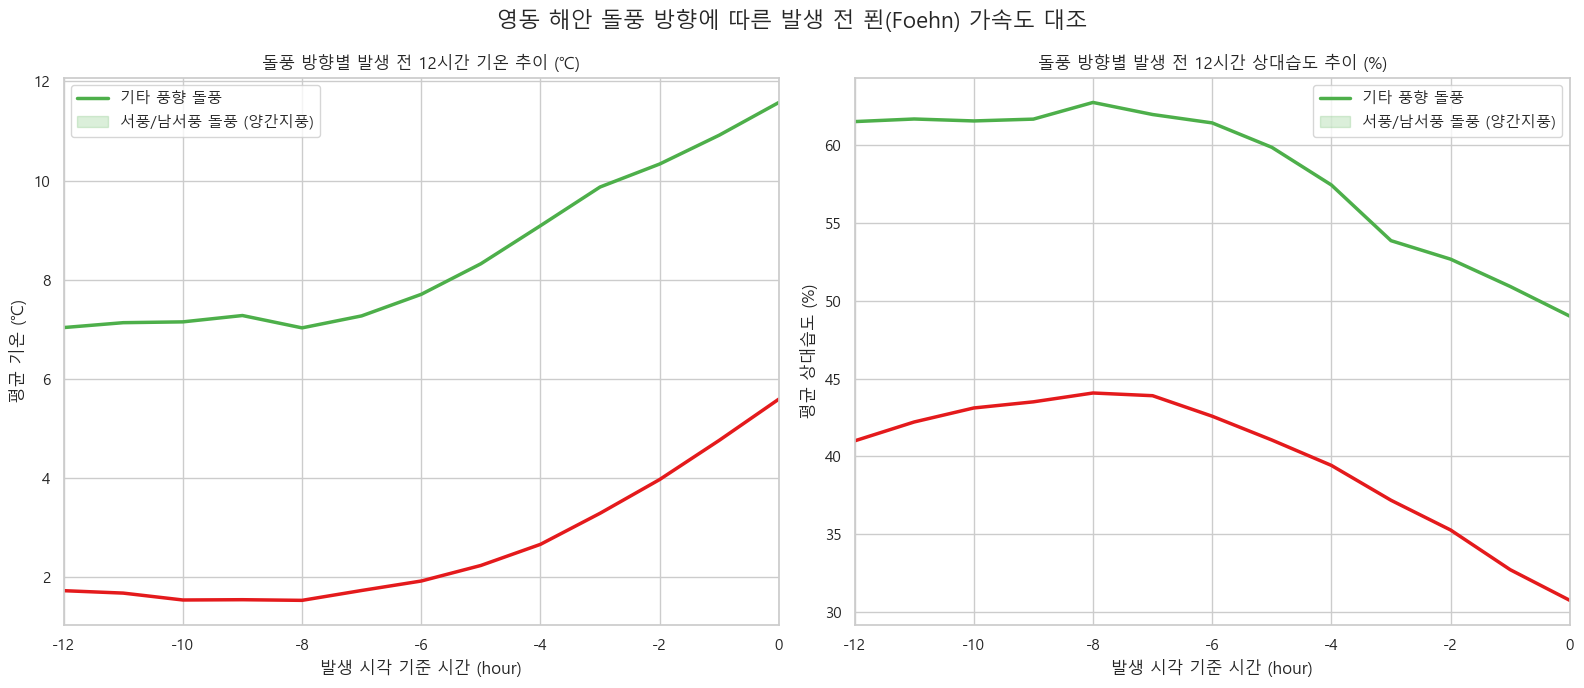

=== 돌풍 그룹별 기온 상승 및 습도 하락 변화량 (-12h -> 0h) ===
서풍/남서풍 돌풍 여부: False | 기온 상승폭=4.54℃, 습도 하락폭=-12.51%p
서풍/남서풍 돌풍 여부: True | 기온 상승폭=3.86℃, 습도 하락폭=-10.25%p


In [22]:
# 15.1. 돌풍 풍향에 따른 발생 전 12시간 기온/습도 시계열 추이 분석
yd_day = day_active[day_active['sub_region'] == '영동 해안'].copy()
yd_day['gust_dir_8'] = yd_day['최대 순간 풍속 풍향'].apply(degrees_to_direction)
yd_day['is_w_sw_gust'] = yd_day['gust_dir_8'].isin(['W', 'SW'])

print("=== 영동 해안 돌풍 풍향 그룹 분포 (서풍/남서풍 여부) ===")
print(yd_day['is_w_sw_gust'].value_counts(dropna=False))

# 시간별 데이터 매핑
id_to_gust_group = yd_day.set_index('산불아이디')['is_w_sw_gust']
gw_hour_yd = gw_hour[gw_hour['sub_region'] == '영동 해안'].copy()
gw_hour_yd['is_w_sw_gust'] = gw_hour_yd['산불아이디'].map(id_to_gust_group)
gw_hour_yd = gw_hour_yd.dropna(subset=['is_w_sw_gust'])

# 발생 전 12시간 시간별 기온/습도 평균 계산
gw_hour_yd_filtered = gw_hour_yd[(gw_hour_yd['발생시각기준시간'] >= -12) & (gw_hour_yd['발생시각기준시간'] <= 0)].copy()
ts_gust = gw_hour_yd_filtered.groupby(['is_w_sw_gust', '발생시각기준시간']).agg(
    mean_temp=('기온', 'mean'),
    mean_rh=('습도', 'mean')
).reset_index()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.lineplot(data=ts_gust, x='발생시각기준시간', y='mean_temp', hue='is_w_sw_gust', linewidth=2.5, ax=axes[0], palette=['#4daf4a', '#e41a1c'])
axes[0].set_title('돌풍 방향별 발생 전 12시간 기온 추이 (℃)')
axes[0].set_xlabel('발생 시각 기준 시간 (hour)')
axes[0].set_ylabel('평균 기온 (℃)')
axes[0].set_xlim(-12, 0)
axes[0].legend(labels=['기타 풍향 돌풍', '서풍/남서풍 돌풍 (양간지풍)'])

sns.lineplot(data=ts_gust, x='발생시각기준시간', y='mean_rh', hue='is_w_sw_gust', linewidth=2.5, ax=axes[1], palette=['#4daf4a', '#e41a1c'])
axes[1].set_title('돌풍 방향별 발생 전 12시간 상대습도 추이 (%)')
axes[1].set_xlabel('발생 시각 기준 시간 (hour)')
axes[1].set_ylabel('평균 상대습도 (%)')
axes[1].set_xlim(-12, 0)
axes[1].legend(labels=['기타 풍향 돌풍', '서풍/남서풍 돌풍 (양간지풍)'])

plt.suptitle('영동 해안 돌풍 방향에 따른 발생 전 푄(Foehn) 가속도 대조', fontsize=16)
plt.tight_layout()
plt.show()

print("=== 돌풍 그룹별 기온 상승 및 습도 하락 변화량 (-12h -> 0h) ===")
for name, group in ts_gust.groupby('is_w_sw_gust'):
    temp_diff = group[group['발생시각기준시간'] == 0]['mean_temp'].values[0] - group[group['발생시각기준시간'] == -12]['mean_temp'].values[0]
    rh_diff = group[group['발생시각기준시간'] == 0]['mean_rh'].values[0] - group[group['발생시각기준시간'] == -12]['mean_rh'].values[0]
    print(f"서풍/남서풍 돌풍 여부: {name} | 기온 상승폭={temp_diff:.2f}℃, 습도 하락폭={rh_diff:.2f}%p")

돌풍 세기-최소 상대습도 Pearson r: -0.4637 (p=1.3671e-86)
돌풍 세기-평균 기온 Pearson r: -0.1438 (p=6.8004e-09)


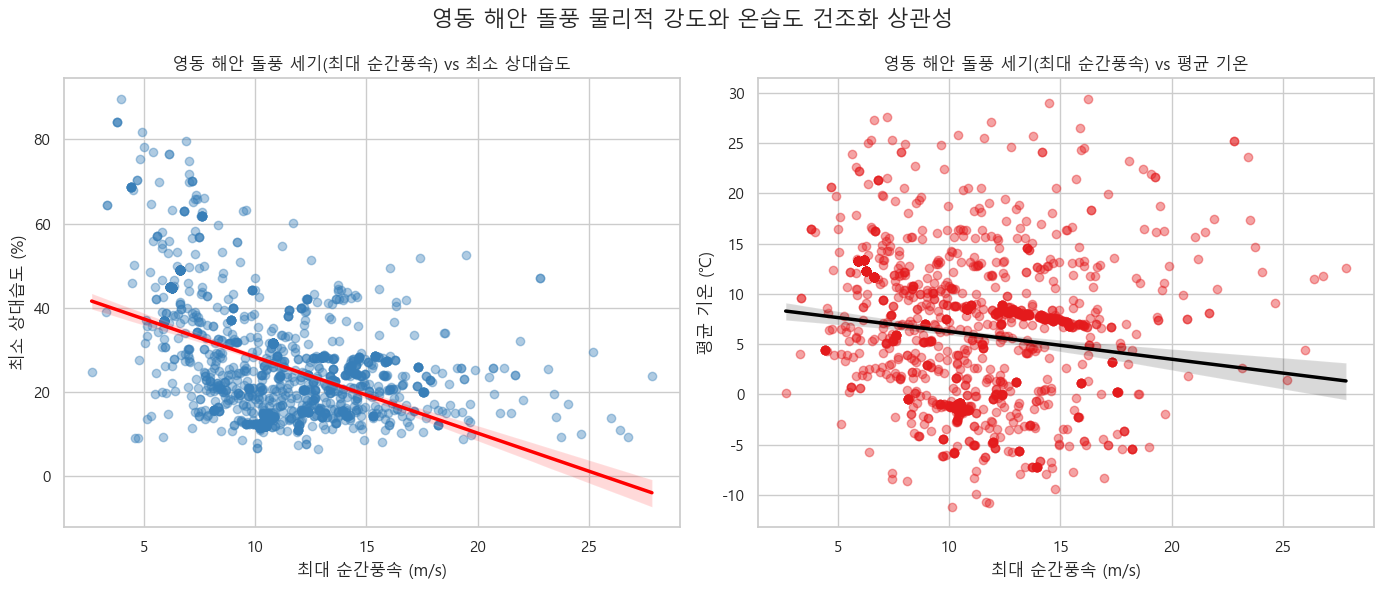

In [24]:
# 15.2. 돌풍 세기(최대 순간풍속)와 최소 상대습도/기온 간의 산점도 및 선형 회귀선 적합
yd_day_valid = yd_day.dropna(subset=['최대 순간풍속', '최소 상대습도', '평균 기온']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(data=yd_day_valid, x='최대 순간풍속', y='최소 상대습도', scatter_kws={'alpha':0.4, 'color':'#377eb8'}, line_kws={'color':'red', 'linewidth':2.5}, ax=axes[0])
axes[0].set_title('영동 해안 돌풍 세기(최대 순간풍속) vs 최소 상대습도')
axes[0].set_xlabel('최대 순간풍속 (m/s)')
axes[0].set_ylabel('최소 상대습도 (%)')

sns.regplot(data=yd_day_valid, x='최대 순간풍속', y='평균 기온', scatter_kws={'alpha':0.4, 'color':'#e41a1c'}, line_kws={'color':'black', 'linewidth':2.5}, ax=axes[1])
axes[1].set_title('영동 해안 돌풍 세기(최대 순간풍속) vs 평균 기온')
axes[1].set_xlabel('최대 순간풍속 (m/s)')
axes[1].set_ylabel('평균 기온 (℃)')

# 상관계수 계산
r_wind_rh, p_wind_rh = stats.pearsonr(yd_day_valid['최대 순간풍속'], yd_day_valid['최소 상대습도'])
r_wind_temp, p_wind_temp = stats.pearsonr(yd_day_valid['최대 순간풍속'], yd_day_valid['평균 기온'])
print(f"돌풍 세기-최소 상대습도 Pearson r: {r_wind_rh:.4f} (p={p_wind_rh:.4e})")
print(f"돌풍 세기-평균 기온 Pearson r: {r_wind_temp:.4f} (p={p_wind_temp:.4e})")

plt.suptitle('영동 해안 돌풍 물리적 강도와 온습도 건조화 상관성', fontsize=16)
plt.tight_layout()
plt.show()

### 15.3. 돌풍(최대 순간 풍속 풍향)과 푄 효과의 다차원 동조성 분석 해석 및 요약 (플롯 이미지 시각 검토 반영)

- **돌풍 풍향 구성**: 영동 해안에서 최대 순간풍속 풍향이 W/SW인 산불은 **944건**, 그 외 풍향은 **665건**입니다. W/SW 돌풍이 더 많은 비중을 차지합니다.
- **발생 전 12시간 변화**: W/SW 돌풍 그룹은 발생 전부터 낮은 습도가 유지되고, 0h로 갈수록 추가 건조화됩니다. 기타 풍향 그룹은 기온 상승폭 **4.54℃**, 습도 하락폭 **-12.51%p**이고, W/SW 그룹은 기온 상승폭 **3.86℃**, 습도 하락폭 **-10.25%p**입니다. 즉 W/SW 그룹은 변화폭 자체보다 **이미 낮은 습도에서 출발하는 누적 건조 상태**가 중요합니다.
- **돌풍 강도와 건조도**: 최대 순간풍속과 최소 상대습도는 Pearson $r=-0.4637$($p=1.37e-86$)로 강한 음의 상관을 보입니다. 돌풍이 강할수록 상대습도가 낮아지는 대기 탈수 동조가 뚜렷합니다.
- **기온과의 관계**: 최대 순간풍속과 평균 기온은 약한 음의 상관($r=-0.1438$, $p=6.80e-09$)입니다. 영동 해안의 위험 돌풍은 단순 고온 열풍이라기보다, 저온·저습·강풍이 결합된 한랭 건조형 돌풍으로 해석하는 것이 타당합니다.
